In [3]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Loading data from pipeline...")

# Load the 6 variables from the saved pickle file
with open('../data/processed/processed_data.pkl', 'rb') as f:
    X_train_balanced, y_train_balanced, X_test_scaled, y_test, X_train_scaled, y_train = pickle.load(f)

# Convert Target Labels from String to Numeric (1 for Churn, 0 for Stay)
y_train_balanced = y_train_balanced.map({'Existing Customer': 0, 'Attrited Customer': 1})
y_test = y_test.map({'Existing Customer': 0, 'Attrited Customer': 1})
y_train = y_train.map({'Existing Customer': 0, 'Attrited Customer': 1})

print("✓ Data loaded and labels encoded successfully!")
print(f"  Shape of X_train_scaled (for CV): {X_train_scaled.shape}")
print(f"  Shape of X_train_balanced (for final train): {X_train_balanced.shape}")
print(f"  Shape of X_test_scaled: {X_test_scaled.shape}")

Loading data from pipeline...
✓ Data loaded and labels encoded successfully!
  Shape of X_train_scaled (for CV): (8101, 21)
  Shape of X_train_balanced (for final train): (13598, 21)
  Shape of X_test_scaled: (2026, 21)


# PHASE 4A: Advanced Hyperparameter Tuning with Optuna

## Objective
Use Optuna to find optimal hyperparameters for our champion model (CatBoost/LightGBM).
We will maximize F1-Score while maintaining cross-validation stability (no data leakage).


In [24]:
# Install required packages
!pip install optuna shap -q

In [4]:
# Import required libraries
import numpy as np
import pandas as pd
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
import shap
import matplotlib.pyplot as plt

# Convert target labels from string to numeric (if needed)
if y_train.dtype == 'object':
    y_train_map = {'Existing Customer': 0, 'Attrited Customer': 1}
    y_train = np.array([y_train_map.get(val, val) for val in y_train], dtype=int)
    y_test = np.array([y_train_map.get(val, val) for val in y_test], dtype=int)

print(f"✓ Class distribution - Train: {np.bincount(y_train)} | Test: {np.bincount(y_test)}")

✓ Class distribution - Train: [6799 1302] | Test: [1701  325]


## Step 1: Define Optuna Objective Function for LightGBM
We'll use 5-Fold Stratified Cross-Validation with ImbPipeline to prevent data leakage.
Optuna will maximize F1-Score while exploring hyperparameter space efficiently.


In [5]:
def create_lightgbm_objective(X, y):
    """
    Creates an Optuna objective function for LightGBM hyperparameter tuning.
    Uses 5-Fold Stratified CV with ImbPipeline (SMOTE applied during each fold).
    """
    def objective(trial):
        # Suggest hyperparameters
        params = {
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 10.0, log=True),
            'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 10.0),
            'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 10.0),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        }
        
        # Create LightGBM model with suggested params
        # Early_stopping_rounds removed as it requires eval_set which is not available with cross_validate()
        lgb_model = LGBMClassifier(
            **params,
            random_state=42,
            verbose=-1,
            n_estimators=200
        )
        
        # Create pipeline with SMOTE
        pipeline = ImbPipeline(steps=[
            ('smote', SMOTE(random_state=42)),
            ('classifier', lgb_model)
        ])
        
        # Cross-validate with stratified k-fold
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_validate(
            pipeline, X, y,
            cv=skf,
            scoring=['f1', 'precision', 'recall', 'accuracy'],
            n_jobs=-1  # Parallel processing
        )
        
        # Calculate mean F1-Score
        mean_f1 = np.mean(cv_scores['test_f1'])
        
        # Report to Optuna for pruning
        trial.report(mean_f1, step=0)
        
        return mean_f1
    
    return objective

# Pass the SCALED training data to prevent leakage during CV
lgb_objective = create_lightgbm_objective(X_train_scaled, y_train)

print("✓ LightGBM Objective function created successfully!")

✓ LightGBM Objective function created successfully!


# Structure of the objective function
This is a Optuna objective function, used for tuning the hyperparameters of the best model we used, which is LightGBM: The structure is as follows:
+ 'params': hyperparameters of the model
+ 'lgb_model': LightGBM 
+ 'pipeline': preprocessing 
+ 'skf': cross-validation 

## Step 2: Run Optuna Study (LightGBM Tuning)
Run 150 trials to find the optimal hyperparameter combination.

In [6]:
print("="*60)
print("STARTING OPTUNA OPTIMIZATION FOR LIGHTGBM")
print("="*60)

# Create Optuna study with TPE sampler
sampler = TPESampler(seed=42)
pruner = MedianPruner(n_startup_trials=10)

study = optuna.create_study(
    direction='maximize',  # Maximize F1-Score
    sampler=sampler,
    pruner=pruner
)

# Run optimization with callbacks for progress tracking
def callback(study, trial):
    if trial.number % 10 == 0:
        print(f"Trial {trial.number}: F1-Score = {trial.value:.4f}")

study.optimize(lgb_objective, n_trials=150, callbacks=[callback], show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)

[I 2026-04-28 17:08:44,979] A new study created in memory with name: no-name-8d8c84e3-97a6-4134-bce5-81b592a5a617


STARTING OPTUNA OPTIMIZATION FOR LIGHTGBM


Best trial: 0. Best value: 0.899296:   1%|          | 1/150 [00:06<15:56,  6.42s/it]

[I 2026-04-28 17:08:51,398] Trial 0 finished with value: 0.8992960248138596 and parameters: {'num_leaves': 50, 'learning_rate': 0.17254716573280354, 'max_depth': 8, 'min_child_samples': 32, 'min_child_weight': 0.004207988669606638, 'lambda_l1': 1.5599452033620265, 'lambda_l2': 0.5808361216819946, 'feature_fraction': 0.9330880728874675, 'bagging_fraction': 0.8005575058716043}. Best is trial 0 with value: 0.8992960248138596.
Trial 0: F1-Score = 0.8993


Best trial: 0. Best value: 0.899296:   1%|▏         | 2/150 [00:12<14:57,  6.06s/it]

[I 2026-04-28 17:08:57,211] Trial 1 finished with value: 0.8565469569613576 and parameters: {'num_leaves': 77, 'learning_rate': 0.010636066512540286, 'max_depth': 10, 'min_child_samples': 43, 'min_child_weight': 0.0070689749506246055, 'lambda_l1': 1.8182496720710062, 'lambda_l2': 1.8340450985343382, 'feature_fraction': 0.6521211214797689, 'bagging_fraction': 0.762378215816119}. Best is trial 0 with value: 0.8992960248138596.


Best trial: 0. Best value: 0.899296:   2%|▏         | 3/150 [00:16<13:13,  5.40s/it]

[I 2026-04-28 17:09:01,817] Trial 2 finished with value: 0.8712760927848204 and parameters: {'num_leaves': 54, 'learning_rate': 0.023927528765580644, 'max_depth': 7, 'min_child_samples': 11, 'min_child_weight': 0.01474275315991467, 'lambda_l1': 3.663618432936917, 'lambda_l2': 4.56069984217036, 'feature_fraction': 0.8925879806965068, 'bagging_fraction': 0.5998368910791798}. Best is trial 0 with value: 0.8992960248138596.


Best trial: 0. Best value: 0.899296:   3%|▎         | 4/150 [00:17<08:27,  3.48s/it]

[I 2026-04-28 17:09:02,344] Trial 3 finished with value: 0.8638694688995683 and parameters: {'num_leaves': 61, 'learning_rate': 0.05898602410432694, 'max_depth': 3, 'min_child_samples': 32, 'min_child_weight': 0.004809461967501573, 'lambda_l1': 0.6505159298527952, 'lambda_l2': 9.488855372533333, 'feature_fraction': 0.9828160165372797, 'bagging_fraction': 0.9041986740582306}. Best is trial 0 with value: 0.8992960248138596.


Best trial: 0. Best value: 0.899296:   3%|▎         | 5/150 [00:19<06:57,  2.88s/it]

[I 2026-04-28 17:09:04,164] Trial 4 finished with value: 0.8499811733582086 and parameters: {'num_leaves': 44, 'learning_rate': 0.013399060561509796, 'max_depth': 8, 'min_child_samples': 25, 'min_child_weight': 0.003077180271250686, 'lambda_l1': 4.951769101112702, 'lambda_l2': 0.34388521115218396, 'feature_fraction': 0.954660201039391, 'bagging_fraction': 0.6293899908000085}. Best is trial 0 with value: 0.8992960248138596.


Best trial: 0. Best value: 0.899296:   4%|▍         | 6/150 [00:20<05:44,  2.39s/it]

[I 2026-04-28 17:09:05,608] Trial 5 finished with value: 0.8638650724884736 and parameters: {'num_leaves': 73, 'learning_rate': 0.02544166090938368, 'max_depth': 7, 'min_child_samples': 30, 'min_child_weight': 0.0054880470007660455, 'lambda_l1': 9.695846277645586, 'lambda_l2': 7.7513282336111455, 'feature_fraction': 0.9697494707820946, 'bagging_fraction': 0.9474136752138245}. Best is trial 0 with value: 0.8992960248138596.


Best trial: 0. Best value: 0.899296:   5%|▍         | 7/150 [00:21<04:18,  1.80s/it]

[I 2026-04-28 17:09:06,207] Trial 6 finished with value: 0.8969094480567434 and parameters: {'num_leaves': 68, 'learning_rate': 0.15826541904647565, 'max_depth': 3, 'min_child_samples': 14, 'min_child_weight': 0.0015167330688076208, 'lambda_l1': 3.2533033076326436, 'lambda_l2': 3.8867728968948203, 'feature_fraction': 0.6356745158869479, 'bagging_fraction': 0.9143687545759647}. Best is trial 0 with value: 0.8992960248138596.


Best trial: 0. Best value: 0.899296:   5%|▌         | 8/150 [00:22<03:53,  1.64s/it]

[I 2026-04-28 17:09:07,502] Trial 7 finished with value: 0.8721079915959056 and parameters: {'num_leaves': 48, 'learning_rate': 0.023200867504756827, 'max_depth': 7, 'min_child_samples': 11, 'min_child_weight': 1.6172900811143154, 'lambda_l1': 0.7455064367977082, 'lambda_l2': 9.868869366005173, 'feature_fraction': 0.8861223846483287, 'bagging_fraction': 0.5993578407670862}. Best is trial 0 with value: 0.8992960248138596.


Best trial: 8. Best value: 0.903892:   6%|▌         | 9/150 [00:23<03:25,  1.46s/it]

[I 2026-04-28 17:09:08,561] Trial 8 finished with value: 0.9038919797128162 and parameters: {'num_leaves': 20, 'learning_rate': 0.11506408247250169, 'max_depth': 8, 'min_child_samples': 38, 'min_child_weight': 1.2164139351417065, 'lambda_l1': 0.7404465173409036, 'lambda_l2': 3.5846572854427263, 'feature_fraction': 0.5579345297625649, 'bagging_fraction': 0.9315517129377968}. Best is trial 8 with value: 0.9038919797128162.


Best trial: 8. Best value: 0.903892:   7%|▋         | 10/150 [00:24<02:52,  1.24s/it]

[I 2026-04-28 17:09:09,294] Trial 9 finished with value: 0.8237143327367686 and parameters: {'num_leaves': 70, 'learning_rate': 0.026946865572417687, 'max_depth': 3, 'min_child_samples': 19, 'min_child_weight': 0.01998634077852888, 'lambda_l1': 7.29606178338064, 'lambda_l2': 6.3755747135521315, 'feature_fraction': 0.9436063712881633, 'bagging_fraction': 0.7361074625809747}. Best is trial 8 with value: 0.9038919797128162.


Best trial: 8. Best value: 0.903892:   7%|▋         | 11/150 [00:25<02:32,  1.09s/it]

[I 2026-04-28 17:09:10,066] Trial 10 finished with value: 0.8893772093868876 and parameters: {'num_leaves': 21, 'learning_rate': 0.08292797530014898, 'max_depth': 5, 'min_child_samples': 48, 'min_child_weight': 8.258362243762974, 'lambda_l1': 6.902470735691452, 'lambda_l2': 2.579269526014921, 'feature_fraction': 0.5055571924113557, 'bagging_fraction': 0.9846565363770474}. Best is trial 8 with value: 0.9038919797128162.
Trial 10: F1-Score = 0.8894


Best trial: 8. Best value: 0.903892:   8%|▊         | 12/150 [00:26<02:24,  1.05s/it]

[I 2026-04-28 17:09:11,010] Trial 11 finished with value: 0.8989886089537963 and parameters: {'num_leaves': 98, 'learning_rate': 0.19498296799527828, 'max_depth': 9, 'min_child_samples': 37, 'min_child_weight': 0.1900540967132546, 'lambda_l1': 2.362640564998433, 'lambda_l2': 0.4121117384896067, 'feature_fraction': 0.7866454888256146, 'bagging_fraction': 0.7958418179650298}. Best is trial 8 with value: 0.9038919797128162.


Best trial: 12. Best value: 0.906056:   9%|▊         | 13/150 [00:27<02:24,  1.05s/it]

[I 2026-04-28 17:09:12,079] Trial 12 finished with value: 0.9060563320142053 and parameters: {'num_leaves': 21, 'learning_rate': 0.10998144389127804, 'max_depth': 9, 'min_child_samples': 38, 'min_child_weight': 0.2730834958148276, 'lambda_l1': 0.4724097526238986, 'lambda_l2': 2.90913655267625, 'feature_fraction': 0.5167929424672362, 'bagging_fraction': 0.8413463105667582}. Best is trial 12 with value: 0.9060563320142053.


Best trial: 13. Best value: 0.907541:   9%|▉         | 14/150 [00:28<02:22,  1.05s/it]

[I 2026-04-28 17:09:13,105] Trial 13 finished with value: 0.9075412163977624 and parameters: {'num_leaves': 21, 'learning_rate': 0.0913951363113394, 'max_depth': 10, 'min_child_samples': 40, 'min_child_weight': 0.2906505557327003, 'lambda_l1': 0.2554949481054347, 'lambda_l2': 3.012897435936558, 'feature_fraction': 0.5243774000493795, 'bagging_fraction': 0.8654589130129217}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  10%|█         | 15/150 [00:29<02:33,  1.14s/it]

[I 2026-04-28 17:09:14,455] Trial 14 finished with value: 0.9028690970411464 and parameters: {'num_leaves': 33, 'learning_rate': 0.07446430255359504, 'max_depth': 10, 'min_child_samples': 50, 'min_child_weight': 0.12394938373767085, 'lambda_l1': 0.21271302968900574, 'lambda_l2': 5.775718258393615, 'feature_fraction': 0.6075890180846563, 'bagging_fraction': 0.8524635413007553}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  11%|█         | 16/150 [00:30<02:34,  1.16s/it]

[I 2026-04-28 17:09:15,652] Trial 15 finished with value: 0.9005715797712217 and parameters: {'num_leaves': 35, 'learning_rate': 0.10554227628540973, 'max_depth': 10, 'min_child_samples': 42, 'min_child_weight': 0.42725039489513805, 'lambda_l1': 4.13440520410747, 'lambda_l2': 2.160139447756661, 'feature_fraction': 0.7316883756937843, 'bagging_fraction': 0.7102096755334841}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  11%|█▏        | 17/150 [00:31<02:21,  1.06s/it]

[I 2026-04-28 17:09:16,504] Trial 16 finished with value: 0.8859493641684967 and parameters: {'num_leaves': 32, 'learning_rate': 0.044861549316082924, 'max_depth': 5, 'min_child_samples': 25, 'min_child_weight': 0.044286756003748, 'lambda_l1': 5.769491738896778, 'lambda_l2': 3.097007797167165, 'feature_fraction': 0.5136095131955984, 'bagging_fraction': 0.5065896071904618}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  12%|█▏        | 18/150 [00:32<02:18,  1.05s/it]

[I 2026-04-28 17:09:17,516] Trial 17 finished with value: 0.9011922227708885 and parameters: {'num_leaves': 27, 'learning_rate': 0.1171598282138342, 'max_depth': 9, 'min_child_samples': 39, 'min_child_weight': 0.5737169762863559, 'lambda_l1': 2.8471055852412386, 'lambda_l2': 5.06776256871667, 'feature_fraction': 0.7091000687909921, 'bagging_fraction': 0.8510609844100318}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  13%|█▎        | 19/150 [00:33<02:16,  1.04s/it]

[I 2026-04-28 17:09:18,547] Trial 18 finished with value: 0.8862598378995576 and parameters: {'num_leaves': 39, 'learning_rate': 0.048573596831018064, 'max_depth': 9, 'min_child_samples': 5, 'min_child_weight': 3.8563427017545195, 'lambda_l1': 9.309781571936997, 'lambda_l2': 1.728561667390637, 'feature_fraction': 0.5681466265863561, 'bagging_fraction': 0.8589779938998253}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  13%|█▎        | 20/150 [00:34<02:10,  1.01s/it]

[I 2026-04-28 17:09:19,467] Trial 19 finished with value: 0.899813545692292 and parameters: {'num_leaves': 85, 'learning_rate': 0.0758486496987548, 'max_depth': 6, 'min_child_samples': 46, 'min_child_weight': 0.07199895480172855, 'lambda_l1': 1.5232226169728342, 'lambda_l2': 7.4633083129078575, 'feature_fraction': 0.7947374699114328, 'bagging_fraction': 0.6817705748485606}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  14%|█▍        | 21/150 [00:35<02:07,  1.01it/s]

[I 2026-04-28 17:09:20,416] Trial 20 finished with value: 0.8860019686428796 and parameters: {'num_leaves': 26, 'learning_rate': 0.03595293137261921, 'max_depth': 9, 'min_child_samples': 35, 'min_child_weight': 0.333417342145883, 'lambda_l1': 4.452870098751182, 'lambda_l2': 4.333579331824903, 'feature_fraction': 0.6812469497890213, 'bagging_fraction': 0.9969213925248543}. Best is trial 13 with value: 0.9075412163977624.
Trial 20: F1-Score = 0.8860


Best trial: 13. Best value: 0.907541:  15%|█▍        | 22/150 [00:36<02:02,  1.04it/s]

[I 2026-04-28 17:09:21,310] Trial 21 finished with value: 0.9048133512420927 and parameters: {'num_leaves': 20, 'learning_rate': 0.12047779588332055, 'max_depth': 8, 'min_child_samples': 41, 'min_child_weight': 1.5290880656749835, 'lambda_l1': 0.1260742839224933, 'lambda_l2': 3.340098499590434, 'feature_fraction': 0.5528355205298704, 'bagging_fraction': 0.9109014223747265}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  15%|█▌        | 23/150 [00:37<02:04,  1.02it/s]

[I 2026-04-28 17:09:22,349] Trial 22 finished with value: 0.9043597284920837 and parameters: {'num_leaves': 26, 'learning_rate': 0.12608273319834729, 'max_depth': 10, 'min_child_samples': 43, 'min_child_weight': 1.185722516505844, 'lambda_l1': 0.3312137861963402, 'lambda_l2': 3.140321182599708, 'feature_fraction': 0.5557367839713647, 'bagging_fraction': 0.8766097081688075}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  16%|█▌        | 24/150 [00:38<02:11,  1.04s/it]

[I 2026-04-28 17:09:23,532] Trial 23 finished with value: 0.89862044130023 and parameters: {'num_leaves': 42, 'learning_rate': 0.09375261199302208, 'max_depth': 8, 'min_child_samples': 40, 'min_child_weight': 2.9264337561605442, 'lambda_l1': 2.1728921821604654, 'lambda_l2': 1.5401637574566909, 'feature_fraction': 0.5892426190751147, 'bagging_fraction': 0.8170064962868606}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  17%|█▋        | 25/150 [00:39<02:08,  1.03s/it]

[I 2026-04-28 17:09:24,536] Trial 24 finished with value: 0.9053971922511268 and parameters: {'num_leaves': 21, 'learning_rate': 0.14705783469271924, 'max_depth': 9, 'min_child_samples': 45, 'min_child_weight': 0.2540870854666619, 'lambda_l1': 0.1042857028880344, 'lambda_l2': 5.29180615333641, 'feature_fraction': 0.5283939233941415, 'bagging_fraction': 0.9598016552038015}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  17%|█▋        | 26/150 [00:40<02:14,  1.09s/it]

[I 2026-04-28 17:09:25,758] Trial 25 finished with value: 0.9056003170264656 and parameters: {'num_leaves': 35, 'learning_rate': 0.14530294181048123, 'max_depth': 9, 'min_child_samples': 45, 'min_child_weight': 0.20107253778238554, 'lambda_l1': 0.9773340338278869, 'lambda_l2': 6.539711993197971, 'feature_fraction': 0.51049640833885, 'bagging_fraction': 0.9671585399291267}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  18%|█▊        | 27/150 [00:41<02:16,  1.11s/it]

[I 2026-04-28 17:09:26,903] Trial 26 finished with value: 0.8978385167931388 and parameters: {'num_leaves': 31, 'learning_rate': 0.058020624031347875, 'max_depth': 10, 'min_child_samples': 35, 'min_child_weight': 0.0460499579840062, 'lambda_l1': 1.3521994999741964, 'lambda_l2': 6.79210161748688, 'feature_fraction': 0.6173437900474738, 'bagging_fraction': 0.7707706778781556}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  19%|█▊        | 28/150 [00:43<02:18,  1.14s/it]

[I 2026-04-28 17:09:28,118] Trial 27 finished with value: 0.9026596972578259 and parameters: {'num_leaves': 39, 'learning_rate': 0.06497231030656218, 'max_depth': 9, 'min_child_samples': 46, 'min_child_weight': 0.6363503928824578, 'lambda_l1': 1.2017037337698802, 'lambda_l2': 7.812363500474129, 'feature_fraction': 0.5015984336097703, 'bagging_fraction': 0.8243418904778581}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  19%|█▉        | 29/150 [00:44<02:10,  1.08s/it]

[I 2026-04-28 17:09:29,056] Trial 28 finished with value: 0.8990208341520421 and parameters: {'num_leaves': 28, 'learning_rate': 0.0919348080015791, 'max_depth': 6, 'min_child_samples': 27, 'min_child_weight': 0.1378365433526452, 'lambda_l1': 2.6471719980467916, 'lambda_l2': 5.71115950886505, 'feature_fraction': 0.6696822780912637, 'bagging_fraction': 0.8950376577178323}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  20%|██        | 30/150 [00:45<02:11,  1.10s/it]

[I 2026-04-28 17:09:30,201] Trial 29 finished with value: 0.9014399308331263 and parameters: {'num_leaves': 55, 'learning_rate': 0.19280868890112343, 'max_depth': 8, 'min_child_samples': 50, 'min_child_weight': 0.05604343227792674, 'lambda_l1': 1.3466363504856431, 'lambda_l2': 8.61705652899299, 'feature_fraction': 0.5860645334276666, 'bagging_fraction': 0.9752326713005867}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  21%|██        | 31/150 [00:46<01:59,  1.01s/it]

[I 2026-04-28 17:09:30,994] Trial 30 finished with value: 0.8952357769886721 and parameters: {'num_leaves': 37, 'learning_rate': 0.1503258878816791, 'max_depth': 10, 'min_child_samples': 31, 'min_child_weight': 0.02403554616309376, 'lambda_l1': 5.906684303812539, 'lambda_l2': 1.2310934175206762, 'feature_fraction': 0.5389747908234617, 'bagging_fraction': 0.8079416234051991}. Best is trial 13 with value: 0.9075412163977624.
Trial 30: F1-Score = 0.8952


Best trial: 13. Best value: 0.907541:  21%|██▏       | 32/150 [00:46<01:55,  1.02it/s]

[I 2026-04-28 17:09:31,917] Trial 31 finished with value: 0.907323822240833 and parameters: {'num_leaves': 24, 'learning_rate': 0.1483826980870479, 'max_depth': 9, 'min_child_samples': 45, 'min_child_weight': 0.2454304513974378, 'lambda_l1': 0.13750972300153583, 'lambda_l2': 5.3136852244811195, 'feature_fraction': 0.5312230770492316, 'bagging_fraction': 0.9537476668012148}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 13. Best value: 0.907541:  22%|██▏       | 33/150 [00:47<01:50,  1.06it/s]

[I 2026-04-28 17:09:32,777] Trial 32 finished with value: 0.9009161084940924 and parameters: {'num_leaves': 26, 'learning_rate': 0.14525894389811567, 'max_depth': 9, 'min_child_samples': 35, 'min_child_weight': 0.20937652935655468, 'lambda_l1': 1.959422760325909, 'lambda_l2': 6.435740451526785, 'feature_fraction': 0.5304811330643945, 'bagging_fraction': 0.951991976648829}. Best is trial 13 with value: 0.9075412163977624.


Best trial: 33. Best value: 0.90851:  23%|██▎       | 34/150 [00:49<01:59,  1.03s/it] 

[I 2026-04-28 17:09:33,999] Trial 33 finished with value: 0.908509511639134 and parameters: {'num_leaves': 47, 'learning_rate': 0.17391261253156276, 'max_depth': 10, 'min_child_samples': 44, 'min_child_weight': 0.09825751306295893, 'lambda_l1': 0.9700910826311357, 'lambda_l2': 4.532735364285545, 'feature_fraction': 0.5927003757123188, 'bagging_fraction': 0.9303037842964204}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  23%|██▎       | 35/150 [00:50<01:58,  1.03s/it]

[I 2026-04-28 17:09:35,034] Trial 34 finished with value: 0.8973944845334122 and parameters: {'num_leaves': 60, 'learning_rate': 0.17248136292310506, 'max_depth': 10, 'min_child_samples': 43, 'min_child_weight': 0.08805758264432473, 'lambda_l1': 2.0577176227529383, 'lambda_l2': 4.300819840244403, 'feature_fraction': 0.5910361316430952, 'bagging_fraction': 0.8805008606757213}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  24%|██▍       | 36/150 [00:51<02:06,  1.11s/it]

[I 2026-04-28 17:09:36,326] Trial 35 finished with value: 0.9053580738371064 and parameters: {'num_leaves': 49, 'learning_rate': 0.09856562909683143, 'max_depth': 10, 'min_child_samples': 48, 'min_child_weight': 0.713169744525948, 'lambda_l1': 0.7749893516627664, 'lambda_l2': 2.6779458052615155, 'feature_fraction': 0.6374446140684454, 'bagging_fraction': 0.9372803531237963}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  25%|██▍       | 37/150 [00:52<02:02,  1.09s/it]

[I 2026-04-28 17:09:37,360] Trial 36 finished with value: 0.8981508439863142 and parameters: {'num_leaves': 44, 'learning_rate': 0.1295448452669662, 'max_depth': 10, 'min_child_samples': 36, 'min_child_weight': 0.013429028494073752, 'lambda_l1': 3.337401807726042, 'lambda_l2': 4.491870405961755, 'feature_fraction': 0.5658005322906048, 'bagging_fraction': 0.8338156558265725}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  25%|██▌       | 38/150 [00:53<01:51,  1.00it/s]

[I 2026-04-28 17:09:38,152] Trial 37 finished with value: 0.8996027910542848 and parameters: {'num_leaves': 24, 'learning_rate': 0.17912390638020584, 'max_depth': 8, 'min_child_samples': 39, 'min_child_weight': 0.02893207328018182, 'lambda_l1': 1.4150393160316201, 'lambda_l2': 1.0656382535304147, 'feature_fraction': 0.6151345377535984, 'bagging_fraction': 0.7888717419789387}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  26%|██▌       | 39/150 [00:54<01:58,  1.07s/it]

[I 2026-04-28 17:09:39,381] Trial 38 finished with value: 0.9051139031492227 and parameters: {'num_leaves': 55, 'learning_rate': 0.08220089077630864, 'max_depth': 7, 'min_child_samples': 33, 'min_child_weight': 0.3741559161506317, 'lambda_l1': 0.6342096380461014, 'lambda_l2': 2.5326038140915963, 'feature_fraction': 0.8375588687302147, 'bagging_fraction': 0.9118363177662229}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  27%|██▋       | 40/150 [00:54<01:41,  1.08it/s]

[I 2026-04-28 17:09:39,971] Trial 39 finished with value: 0.892785684595831 and parameters: {'num_leaves': 30, 'learning_rate': 0.06379777621839482, 'max_depth': 4, 'min_child_samples': 20, 'min_child_weight': 0.1212296011331726, 'lambda_l1': 0.0059913124446105415, 'lambda_l2': 4.981125251188806, 'feature_fraction': 0.6438141451466806, 'bagging_fraction': 0.8801003655885892}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  27%|██▋       | 41/150 [00:56<01:58,  1.09s/it]

[I 2026-04-28 17:09:41,450] Trial 40 finished with value: 0.8781145679431777 and parameters: {'num_leaves': 61, 'learning_rate': 0.017400385970233974, 'max_depth': 9, 'min_child_samples': 29, 'min_child_weight': 0.7702339146012847, 'lambda_l1': 1.7753271833162731, 'lambda_l2': 3.895676948733001, 'feature_fraction': 0.5437636092320777, 'bagging_fraction': 0.919050474968852}. Best is trial 33 with value: 0.908509511639134.
Trial 40: F1-Score = 0.8781


Best trial: 33. Best value: 0.90851:  28%|██▊       | 42/150 [00:57<01:57,  1.09s/it]

[I 2026-04-28 17:09:42,541] Trial 41 finished with value: 0.9034459329101676 and parameters: {'num_leaves': 35, 'learning_rate': 0.1382589133107108, 'max_depth': 9, 'min_child_samples': 44, 'min_child_weight': 0.1987759007505053, 'lambda_l1': 0.9504625782952885, 'lambda_l2': 5.574701216639796, 'feature_fraction': 0.5220986507894022, 'bagging_fraction': 0.9623465056124607}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  29%|██▊       | 43/150 [00:58<02:02,  1.15s/it]

[I 2026-04-28 17:09:43,811] Trial 42 finished with value: 0.9061257694297048 and parameters: {'num_leaves': 45, 'learning_rate': 0.16717149086529307, 'max_depth': 10, 'min_child_samples': 47, 'min_child_weight': 0.3077880474702931, 'lambda_l1': 0.6593821913411154, 'lambda_l2': 6.180045903590734, 'feature_fraction': 0.5075154108952701, 'bagging_fraction': 0.999273814800576}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  29%|██▉       | 44/150 [01:00<02:04,  1.18s/it]

[I 2026-04-28 17:09:45,061] Trial 43 finished with value: 0.9028265518442529 and parameters: {'num_leaves': 46, 'learning_rate': 0.17752304632963933, 'max_depth': 10, 'min_child_samples': 48, 'min_child_weight': 0.33315584700686784, 'lambda_l1': 0.5552843433351429, 'lambda_l2': 4.872918288662359, 'feature_fraction': 0.5768622995619144, 'bagging_fraction': 0.9327720995860396}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  30%|███       | 45/150 [01:01<01:56,  1.10s/it]

[I 2026-04-28 17:09:45,998] Trial 44 finished with value: 0.9037242258319476 and parameters: {'num_leaves': 23, 'learning_rate': 0.11289188019799491, 'max_depth': 10, 'min_child_samples': 41, 'min_child_weight': 0.08399712326779671, 'lambda_l1': 1.0002745042250787, 'lambda_l2': 4.042704573395669, 'feature_fraction': 0.5022076815021451, 'bagging_fraction': 0.9878755319285378}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  31%|███       | 46/150 [01:02<01:51,  1.08s/it]

[I 2026-04-28 17:09:47,011] Trial 45 finished with value: 0.9011723222914216 and parameters: {'num_leaves': 52, 'learning_rate': 0.16193852327585484, 'max_depth': 10, 'min_child_samples': 47, 'min_child_weight': 0.13828233121788377, 'lambda_l1': 2.66964855865472, 'lambda_l2': 5.97760391856434, 'feature_fraction': 0.5420790086805766, 'bagging_fraction': 0.8933358807060038}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  31%|███▏      | 47/150 [01:02<01:36,  1.07it/s]

[I 2026-04-28 17:09:47,615] Trial 46 finished with value: 0.8889090762994989 and parameters: {'num_leaves': 64, 'learning_rate': 0.19658484318834343, 'max_depth': 8, 'min_child_samples': 38, 'min_child_weight': 0.5020801376712283, 'lambda_l1': 8.609030771728927, 'lambda_l2': 3.5909256526538718, 'feature_fraction': 0.6058449865342466, 'bagging_fraction': 0.9418355666705021}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  32%|███▏      | 48/150 [01:04<01:57,  1.15s/it]

[I 2026-04-28 17:09:49,261] Trial 47 finished with value: 0.9039174220631381 and parameters: {'num_leaves': 77, 'learning_rate': 0.10557322643151132, 'max_depth': 10, 'min_child_samples': 50, 'min_child_weight': 0.26948237125138497, 'lambda_l1': 0.4935155540096483, 'lambda_l2': 7.2164330118777515, 'feature_fraction': 0.917951518973829, 'bagging_fraction': 0.9958122442181188}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  33%|███▎      | 49/150 [01:05<01:50,  1.09s/it]

[I 2026-04-28 17:09:50,219] Trial 48 finished with value: 0.8989938905583621 and parameters: {'num_leaves': 42, 'learning_rate': 0.13349361794557188, 'max_depth': 7, 'min_child_samples': 33, 'min_child_weight': 0.9886904962224854, 'lambda_l1': 3.2298352653432207, 'lambda_l2': 6.060237953735817, 'feature_fraction': 0.5237594902357608, 'bagging_fraction': 0.8457352791638078}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  33%|███▎      | 50/150 [01:06<01:46,  1.06s/it]

[I 2026-04-28 17:09:51,212] Trial 49 finished with value: 0.8984187423243775 and parameters: {'num_leaves': 30, 'learning_rate': 0.15876845087702157, 'max_depth': 9, 'min_child_samples': 42, 'min_child_weight': 2.8218165200114917, 'lambda_l1': 1.5777625129128987, 'lambda_l2': 2.3094644879748643, 'feature_fraction': 0.569834387996139, 'bagging_fraction': 0.8717158517430075}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  34%|███▍      | 51/150 [01:07<01:56,  1.18s/it]

[I 2026-04-28 17:09:52,656] Trial 50 finished with value: 0.9042778110949637 and parameters: {'num_leaves': 58, 'learning_rate': 0.10880534535213396, 'max_depth': 10, 'min_child_samples': 43, 'min_child_weight': 0.0020952480613893212, 'lambda_l1': 0.48889747379339354, 'lambda_l2': 2.850917850123801, 'feature_fraction': 0.6685686352715008, 'bagging_fraction': 0.740506951017686}. Best is trial 33 with value: 0.908509511639134.
Trial 50: F1-Score = 0.9043


Best trial: 33. Best value: 0.90851:  35%|███▍      | 52/150 [01:08<01:52,  1.15s/it]

[I 2026-04-28 17:09:53,732] Trial 51 finished with value: 0.9047715253379502 and parameters: {'num_leaves': 34, 'learning_rate': 0.1617994768299391, 'max_depth': 9, 'min_child_samples': 45, 'min_child_weight': 0.16315618709154733, 'lambda_l1': 0.9982633373335301, 'lambda_l2': 6.836556683961083, 'feature_fraction': 0.5055034542501253, 'bagging_fraction': 0.9779936722332637}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  35%|███▌      | 53/150 [01:10<01:54,  1.19s/it]

[I 2026-04-28 17:09:55,004] Trial 52 finished with value: 0.891653589264139 and parameters: {'num_leaves': 40, 'learning_rate': 0.03525141160996476, 'max_depth': 9, 'min_child_samples': 45, 'min_child_weight': 0.4415389618998551, 'lambda_l1': 1.00482665142155, 'lambda_l2': 6.573764262320097, 'feature_fraction': 0.5264375878760784, 'bagging_fraction': 0.9659632100092376}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  36%|███▌      | 54/150 [01:11<01:55,  1.20s/it]

[I 2026-04-28 17:09:56,239] Trial 53 finished with value: 0.9039073125001849 and parameters: {'num_leaves': 48, 'learning_rate': 0.13357919519291628, 'max_depth': 9, 'min_child_samples': 47, 'min_child_weight': 0.06357747743324091, 'lambda_l1': 1.830859956812336, 'lambda_l2': 8.289922468690374, 'feature_fraction': 0.5499959963217351, 'bagging_fraction': 0.9290139137595861}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  37%|███▋      | 55/150 [01:12<01:49,  1.15s/it]

[I 2026-04-28 17:09:57,281] Trial 54 finished with value: 0.9056251874831075 and parameters: {'num_leaves': 24, 'learning_rate': 0.08879318640414292, 'max_depth': 10, 'min_child_samples': 40, 'min_child_weight': 0.10274982268499214, 'lambda_l1': 0.083343941930482, 'lambda_l2': 5.240171876509615, 'feature_fraction': 0.5042493338007767, 'bagging_fraction': 0.9009332715986649}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  37%|███▋      | 56/150 [01:13<01:42,  1.09s/it]

[I 2026-04-28 17:09:58,239] Trial 55 finished with value: 0.905789951979812 and parameters: {'num_leaves': 24, 'learning_rate': 0.08707452673735702, 'max_depth': 10, 'min_child_samples': 40, 'min_child_weight': 0.10273809407798463, 'lambda_l1': 0.00579942691025867, 'lambda_l2': 5.396360643704715, 'feature_fraction': 0.5572645044419238, 'bagging_fraction': 0.899120083767255}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  38%|███▊      | 57/150 [01:14<01:37,  1.05s/it]

[I 2026-04-28 17:09:59,183] Trial 56 finished with value: 0.906688325618686 and parameters: {'num_leaves': 20, 'learning_rate': 0.07516162732489254, 'max_depth': 10, 'min_child_samples': 37, 'min_child_weight': 0.03620462506543492, 'lambda_l1': 0.4189140125675536, 'lambda_l2': 2.0719173107421787, 'feature_fraction': 0.601574335808383, 'bagging_fraction': 0.6318713596947096}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  39%|███▊      | 58/150 [01:15<01:33,  1.02s/it]

[I 2026-04-28 17:10:00,135] Trial 57 finished with value: 0.9050750721443255 and parameters: {'num_leaves': 22, 'learning_rate': 0.07695049289412782, 'max_depth': 10, 'min_child_samples': 36, 'min_child_weight': 0.00980557319718969, 'lambda_l1': 0.46473427959304636, 'lambda_l2': 1.8168401857005712, 'feature_fraction': 0.6014956524711026, 'bagging_fraction': 0.5433986015999095}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  39%|███▉      | 59/150 [01:16<01:46,  1.17s/it]

[I 2026-04-28 17:10:01,661] Trial 58 finished with value: 0.8972190080926623 and parameters: {'num_leaves': 87, 'learning_rate': 0.07078079510140473, 'max_depth': 10, 'min_child_samples': 38, 'min_child_weight': 0.03204688818309009, 'lambda_l1': 2.3859818567768007, 'lambda_l2': 3.5728437171196883, 'feature_fraction': 0.7603854629574149, 'bagging_fraction': 0.6158388645238249}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  40%|████      | 60/150 [01:17<01:38,  1.09s/it]

[I 2026-04-28 17:10:02,572] Trial 59 finished with value: 0.8380833091361068 and parameters: {'num_leaves': 20, 'learning_rate': 0.010372866144614884, 'max_depth': 9, 'min_child_samples': 42, 'min_child_weight': 0.298609816324232, 'lambda_l1': 0.34835267518311497, 'lambda_l2': 0.06352937593683183, 'feature_fraction': 0.6992701609324903, 'bagging_fraction': 0.5670654048811654}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  41%|████      | 61/150 [01:18<01:33,  1.05s/it]

[I 2026-04-28 17:10:03,530] Trial 60 finished with value: 0.8971662387584557 and parameters: {'num_leaves': 29, 'learning_rate': 0.05623664858007894, 'max_depth': 8, 'min_child_samples': 33, 'min_child_weight': 0.04239901162663012, 'lambda_l1': 4.169046360698146, 'lambda_l2': 0.8481814146935047, 'feature_fraction': 0.6252485287939609, 'bagging_fraction': 0.6589257127715682}. Best is trial 33 with value: 0.908509511639134.
Trial 60: F1-Score = 0.8972


Best trial: 33. Best value: 0.90851:  41%|████▏     | 62/150 [01:19<01:30,  1.03s/it]

[I 2026-04-28 17:10:04,501] Trial 61 finished with value: 0.9048564061031694 and parameters: {'num_leaves': 24, 'learning_rate': 0.1196215207919711, 'max_depth': 10, 'min_child_samples': 41, 'min_child_weight': 0.08393112200333198, 'lambda_l1': 0.7321019465011349, 'lambda_l2': 4.797274266227152, 'feature_fraction': 0.5604954201933303, 'bagging_fraction': 0.6716100211498043}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  42%|████▏     | 63/150 [01:20<01:28,  1.01s/it]

[I 2026-04-28 17:10:05,477] Trial 62 finished with value: 0.9043411366221786 and parameters: {'num_leaves': 27, 'learning_rate': 0.09919244416376019, 'max_depth': 10, 'min_child_samples': 39, 'min_child_weight': 0.056545071925624156, 'lambda_l1': 0.00200897709347303, 'lambda_l2': 2.113905638049903, 'feature_fraction': 0.5843255627960859, 'bagging_fraction': 0.8669682671521172}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  43%|████▎     | 64/150 [01:21<01:22,  1.04it/s]

[I 2026-04-28 17:10:06,314] Trial 63 finished with value: 0.9013920587529674 and parameters: {'num_leaves': 20, 'learning_rate': 0.08561222092388353, 'max_depth': 10, 'min_child_samples': 44, 'min_child_weight': 0.018321277003281646, 'lambda_l1': 1.2519855138386309, 'lambda_l2': 5.395482384737128, 'feature_fraction': 0.5374612179729183, 'bagging_fraction': 0.776645334732077}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  43%|████▎     | 65/150 [01:22<01:24,  1.00it/s]

[I 2026-04-28 17:10:07,390] Trial 64 finished with value: 0.9037208353876235 and parameters: {'num_leaves': 32, 'learning_rate': 0.09983286838757635, 'max_depth': 9, 'min_child_samples': 37, 'min_child_weight': 0.16020440434004216, 'lambda_l1': 0.2814257716102046, 'lambda_l2': 6.097668844255942, 'feature_fraction': 0.553911271532898, 'bagging_fraction': 0.8390928702817891}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  44%|████▍     | 66/150 [01:23<01:19,  1.05it/s]

[I 2026-04-28 17:10:08,244] Trial 65 finished with value: 0.9026520597665592 and parameters: {'num_leaves': 25, 'learning_rate': 0.052161657075575726, 'max_depth': 10, 'min_child_samples': 49, 'min_child_weight': 0.21574969131791646, 'lambda_l1': 0.7176559756035822, 'lambda_l2': 3.386631211992714, 'feature_fraction': 0.5195048078850154, 'bagging_fraction': 0.7099014307727973}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  45%|████▍     | 67/150 [01:24<01:22,  1.01it/s]

[I 2026-04-28 17:10:09,317] Trial 66 finished with value: 0.8974574214255396 and parameters: {'num_leaves': 66, 'learning_rate': 0.065530574530715, 'max_depth': 9, 'min_child_samples': 46, 'min_child_weight': 0.11267609178945262, 'lambda_l1': 5.6885447470226085, 'lambda_l2': 1.4138905339727812, 'feature_fraction': 0.5952722927388685, 'bagging_fraction': 0.9473939408670403}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  45%|████▌     | 68/150 [01:25<01:19,  1.03it/s]

[I 2026-04-28 17:10:10,230] Trial 67 finished with value: 0.8897543735594035 and parameters: {'num_leaves': 28, 'learning_rate': 0.04059219172264848, 'max_depth': 6, 'min_child_samples': 40, 'min_child_weight': 0.038083563940233704, 'lambda_l1': 1.583966889533699, 'lambda_l2': 4.170000209695935, 'feature_fraction': 0.6270844453981157, 'bagging_fraction': 0.9194742541966372}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  46%|████▌     | 69/150 [01:26<01:23,  1.03s/it]

[I 2026-04-28 17:10:11,400] Trial 68 finished with value: 0.9044620095106627 and parameters: {'num_leaves': 37, 'learning_rate': 0.1242944916376525, 'max_depth': 10, 'min_child_samples': 44, 'min_child_weight': 0.25393156767128766, 'lambda_l1': 1.196325792587162, 'lambda_l2': 4.7707016526667525, 'feature_fraction': 0.574263954680877, 'bagging_fraction': 0.9001327325539997}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  47%|████▋     | 70/150 [01:27<01:13,  1.09it/s]

[I 2026-04-28 17:10:12,066] Trial 69 finished with value: 0.8278253199419906 and parameters: {'num_leaves': 22, 'learning_rate': 0.012333848241553163, 'max_depth': 4, 'min_child_samples': 7, 'min_child_weight': 0.44675600868528187, 'lambda_l1': 0.3268774744004196, 'lambda_l2': 3.0532096721224016, 'feature_fraction': 0.5376606002654389, 'bagging_fraction': 0.8585668057523974}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  47%|████▋     | 71/150 [01:27<01:07,  1.17it/s]

[I 2026-04-28 17:10:12,778] Trial 70 finished with value: 0.8939042591074626 and parameters: {'num_leaves': 32, 'learning_rate': 0.17652722481974176, 'max_depth': 10, 'min_child_samples': 21, 'min_child_weight': 0.7871443988634065, 'lambda_l1': 7.29217128291376, 'lambda_l2': 4.597856573165051, 'feature_fraction': 0.5605296706204216, 'bagging_fraction': 0.7064025123573497}. Best is trial 33 with value: 0.908509511639134.
Trial 70: F1-Score = 0.8939


Best trial: 33. Best value: 0.90851:  48%|████▊     | 72/150 [01:28<01:07,  1.16it/s]

[I 2026-04-28 17:10:13,660] Trial 71 finished with value: 0.9040513873315847 and parameters: {'num_leaves': 23, 'learning_rate': 0.08275786341563904, 'max_depth': 10, 'min_child_samples': 40, 'min_child_weight': 0.09038197131784431, 'lambda_l1': 0.007609188387024901, 'lambda_l2': 5.177558756091094, 'feature_fraction': 0.5143529972530831, 'bagging_fraction': 0.8932538023250819}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  49%|████▊     | 73/150 [01:29<01:11,  1.08it/s]

[I 2026-04-28 17:10:14,743] Trial 72 finished with value: 0.9050264614413992 and parameters: {'num_leaves': 26, 'learning_rate': 0.09276006819181729, 'max_depth': 10, 'min_child_samples': 37, 'min_child_weight': 0.09966502633530595, 'lambda_l1': 0.7754707103772099, 'lambda_l2': 5.450430573849602, 'feature_fraction': 0.5046779007193931, 'bagging_fraction': 0.9230214082278577}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  49%|████▉     | 74/150 [01:30<01:09,  1.10it/s]

[I 2026-04-28 17:10:15,604] Trial 73 finished with value: 0.9036057162816171 and parameters: {'num_leaves': 20, 'learning_rate': 0.0729631995306006, 'max_depth': 10, 'min_child_samples': 42, 'min_child_weight': 0.15568705338104563, 'lambda_l1': 0.24053433642050398, 'lambda_l2': 5.814202983413736, 'feature_fraction': 0.5255686035917472, 'bagging_fraction': 0.9497928250366617}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  50%|█████     | 75/150 [01:31<01:08,  1.09it/s]

[I 2026-04-28 17:10:16,535] Trial 74 finished with value: 0.9039017489022971 and parameters: {'num_leaves': 24, 'learning_rate': 0.08505665541284545, 'max_depth': 9, 'min_child_samples': 39, 'min_child_weight': 0.06283965596606106, 'lambda_l1': 0.2752854489954675, 'lambda_l2': 6.280163896539242, 'feature_fraction': 0.5458745139464735, 'bagging_fraction': 0.9087155141788935}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  51%|█████     | 76/150 [01:32<01:10,  1.04it/s]

[I 2026-04-28 17:10:17,590] Trial 75 finished with value: 0.9044248416463404 and parameters: {'num_leaves': 29, 'learning_rate': 0.1150070550678581, 'max_depth': 10, 'min_child_samples': 34, 'min_child_weight': 0.3407762207667675, 'lambda_l1': 0.8763757754198064, 'lambda_l2': 3.800913471575109, 'feature_fraction': 0.5002394452845118, 'bagging_fraction': 0.8237298089433658}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  51%|█████▏    | 77/150 [01:33<01:09,  1.05it/s]

[I 2026-04-28 17:10:18,528] Trial 76 finished with value: 0.9043893236366218 and parameters: {'num_leaves': 22, 'learning_rate': 0.14730045031821742, 'max_depth': 10, 'min_child_samples': 41, 'min_child_weight': 0.5844611036352368, 'lambda_l1': 1.2289603000640468, 'lambda_l2': 2.1457429650609328, 'feature_fraction': 0.5815615617412218, 'bagging_fraction': 0.8865304641110562}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  52%|█████▏    | 78/150 [01:34<01:08,  1.05it/s]

[I 2026-04-28 17:10:19,486] Trial 77 finished with value: 0.904310436208106 and parameters: {'num_leaves': 25, 'learning_rate': 0.09154040201144946, 'max_depth': 9, 'min_child_samples': 31, 'min_child_weight': 0.111255524876219, 'lambda_l1': 0.0006577919735327176, 'lambda_l2': 5.135262485492446, 'feature_fraction': 0.5150815620221084, 'bagging_fraction': 0.9764831878443008}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  53%|█████▎    | 79/150 [01:36<01:20,  1.13s/it]

[I 2026-04-28 17:10:21,041] Trial 78 finished with value: 0.906973074081405 and parameters: {'num_leaves': 100, 'learning_rate': 0.10512442055930141, 'max_depth': 9, 'min_child_samples': 47, 'min_child_weight': 0.2513497660127946, 'lambda_l1': 0.53212873981655, 'lambda_l2': 5.653638944170237, 'feature_fraction': 0.8363065053422941, 'bagging_fraction': 0.9072206281387525}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  53%|█████▎    | 80/150 [01:37<01:21,  1.16s/it]

[I 2026-04-28 17:10:22,249] Trial 79 finished with value: 0.9048887666256251 and parameters: {'num_leaves': 46, 'learning_rate': 0.10421500870111185, 'max_depth': 8, 'min_child_samples': 47, 'min_child_weight': 0.24159948627276628, 'lambda_l1': 1.6231739424762683, 'lambda_l2': 7.04277292824522, 'feature_fraction': 0.8463539306362479, 'bagging_fraction': 0.9572845993416139}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  54%|█████▍    | 81/150 [01:38<01:19,  1.15s/it]

[I 2026-04-28 17:10:23,395] Trial 80 finished with value: 0.9049483332088017 and parameters: {'num_leaves': 90, 'learning_rate': 0.1415926686136136, 'max_depth': 8, 'min_child_samples': 49, 'min_child_weight': 0.18000982095590862, 'lambda_l1': 0.5669295943946033, 'lambda_l2': 2.755856928933998, 'feature_fraction': 0.820060463488109, 'bagging_fraction': 0.9338937247984256}. Best is trial 33 with value: 0.908509511639134.
Trial 80: F1-Score = 0.9049


Best trial: 33. Best value: 0.90851:  55%|█████▍    | 82/150 [01:40<01:28,  1.30s/it]

[I 2026-04-28 17:10:25,040] Trial 81 finished with value: 0.9044447746133109 and parameters: {'num_leaves': 99, 'learning_rate': 0.1097493669783708, 'max_depth': 9, 'min_child_samples': 43, 'min_child_weight': 0.3569401977199283, 'lambda_l1': 0.48806167482832563, 'lambda_l2': 5.5943378029438655, 'feature_fraction': 0.9959631110905053, 'bagging_fraction': 0.9054399823807879}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  55%|█████▌    | 83/150 [01:41<01:27,  1.30s/it]

[I 2026-04-28 17:10:26,333] Trial 82 finished with value: 0.9019291256274004 and parameters: {'num_leaves': 94, 'learning_rate': 0.12412942406010143, 'max_depth': 10, 'min_child_samples': 48, 'min_child_weight': 0.1290455956112262, 'lambda_l1': 0.9777561600634992, 'lambda_l2': 4.414634476945496, 'feature_fraction': 0.8708180121282697, 'bagging_fraction': 0.8676971366459444}. Best is trial 33 with value: 0.908509511639134.


Best trial: 33. Best value: 0.90851:  56%|█████▌    | 84/150 [01:42<01:30,  1.38s/it]

[I 2026-04-28 17:10:27,894] Trial 83 finished with value: 0.9045504384664907 and parameters: {'num_leaves': 72, 'learning_rate': 0.06795181182900703, 'max_depth': 10, 'min_child_samples': 45, 'min_child_weight': 0.005582109823098994, 'lambda_l1': 0.22466177459546305, 'lambda_l2': 6.242042041558688, 'feature_fraction': 0.7314059846813451, 'bagging_fraction': 0.9920375823156956}. Best is trial 33 with value: 0.908509511639134.


Best trial: 84. Best value: 0.909035:  57%|█████▋    | 85/150 [01:44<01:27,  1.35s/it]

[I 2026-04-28 17:10:29,185] Trial 84 finished with value: 0.9090345998045903 and parameters: {'num_leaves': 82, 'learning_rate': 0.16963001093209412, 'max_depth': 9, 'min_child_samples': 40, 'min_child_weight': 0.07447421297727555, 'lambda_l1': 1.1469656970949158, 'lambda_l2': 5.8299963942808075, 'feature_fraction': 0.9172677610819773, 'bagging_fraction': 0.8809529793867712}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  57%|█████▋    | 86/150 [01:45<01:29,  1.39s/it]

[I 2026-04-28 17:10:30,668] Trial 85 finished with value: 0.9018705383795769 and parameters: {'num_leaves': 75, 'learning_rate': 0.19133987722747176, 'max_depth': 9, 'min_child_samples': 46, 'min_child_weight': 0.07763371563687213, 'lambda_l1': 1.1462956698046818, 'lambda_l2': 5.8756127433728125, 'feature_fraction': 0.9448043179090101, 'bagging_fraction': 0.8579472904564455}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  58%|█████▊    | 87/150 [01:46<01:20,  1.28s/it]

[I 2026-04-28 17:10:31,678] Trial 86 finished with value: 0.9051628911220817 and parameters: {'num_leaves': 84, 'learning_rate': 0.16798286457570397, 'max_depth': 9, 'min_child_samples': 38, 'min_child_weight': 0.04752402728260249, 'lambda_l1': 2.3007061462863807, 'lambda_l2': 2.407556230390109, 'feature_fraction': 0.8781914197227008, 'bagging_fraction': 0.8005204912018117}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  59%|█████▊    | 88/150 [01:48<01:25,  1.38s/it]

[I 2026-04-28 17:10:33,297] Trial 87 finished with value: 0.9021137699373336 and parameters: {'num_leaves': 83, 'learning_rate': 0.0771688677775479, 'max_depth': 9, 'min_child_samples': 36, 'min_child_weight': 0.031240443651564958, 'lambda_l1': 0.6914829917402712, 'lambda_l2': 5.6110146880959855, 'feature_fraction': 0.9746625739945268, 'bagging_fraction': 0.8821172925035794}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  59%|█████▉    | 89/150 [01:49<01:14,  1.22s/it]

[I 2026-04-28 17:10:34,143] Trial 88 finished with value: 0.9072255058012193 and parameters: {'num_leaves': 80, 'learning_rate': 0.15558954834632405, 'max_depth': 5, 'min_child_samples': 43, 'min_child_weight': 0.022610104146700893, 'lambda_l1': 1.8572063673811483, 'lambda_l2': 6.700675336358863, 'feature_fraction': 0.9027319676102912, 'bagging_fraction': 0.8369166930064139}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  60%|██████    | 90/150 [01:49<01:05,  1.09s/it]

[I 2026-04-28 17:10:34,917] Trial 89 finished with value: 0.9018771261262808 and parameters: {'num_leaves': 94, 'learning_rate': 0.15978459992317948, 'max_depth': 5, 'min_child_samples': 44, 'min_child_weight': 0.013424266313257029, 'lambda_l1': 2.0720179449617024, 'lambda_l2': 6.654477072132849, 'feature_fraction': 0.9127372920873053, 'bagging_fraction': 0.8369758176770424}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  61%|██████    | 91/150 [01:50<00:59,  1.01s/it]

[I 2026-04-28 17:10:35,748] Trial 90 finished with value: 0.9026127720469683 and parameters: {'num_leaves': 69, 'learning_rate': 0.18448578260733178, 'max_depth': 5, 'min_child_samples': 42, 'min_child_weight': 0.021957724264836512, 'lambda_l1': 1.5064770749509715, 'lambda_l2': 7.6203978325619115, 'feature_fraction': 0.9025154347370781, 'bagging_fraction': 0.7882909092010235}. Best is trial 84 with value: 0.9090345998045903.
Trial 90: F1-Score = 0.9026


Best trial: 84. Best value: 0.909035:  61%|██████▏   | 92/150 [01:51<00:52,  1.11it/s]

[I 2026-04-28 17:10:36,403] Trial 91 finished with value: 0.8948489046578475 and parameters: {'num_leaves': 51, 'learning_rate': 0.15379335981260317, 'max_depth': 4, 'min_child_samples': 46, 'min_child_weight': 0.28268709073025733, 'lambda_l1': 1.7592987265364899, 'lambda_l2': 6.432886171697899, 'feature_fraction': 0.947629634275807, 'bagging_fraction': 0.8111935079713674}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  62%|██████▏   | 93/150 [01:52<00:46,  1.23it/s]

[I 2026-04-28 17:10:37,004] Trial 92 finished with value: 0.8955210341327955 and parameters: {'num_leaves': 81, 'learning_rate': 0.13129888116642074, 'max_depth': 3, 'min_child_samples': 43, 'min_child_weight': 0.01618256866445384, 'lambda_l1': 0.6002645752978776, 'lambda_l2': 6.1273174504354175, 'feature_fraction': 0.8544273262843448, 'bagging_fraction': 0.8472075643255894}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  63%|██████▎   | 94/150 [01:53<00:51,  1.08it/s]

[I 2026-04-28 17:10:38,184] Trial 93 finished with value: 0.9049762114414174 and parameters: {'num_leaves': 80, 'learning_rate': 0.17297982014839855, 'max_depth': 6, 'min_child_samples': 41, 'min_child_weight': 0.06932438329690653, 'lambda_l1': 0.8341689332106004, 'lambda_l2': 7.043090914057893, 'feature_fraction': 0.9315522310501533, 'bagging_fraction': 0.7568002865519877}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  63%|██████▎   | 95/150 [01:54<00:53,  1.03it/s]

[I 2026-04-28 17:10:39,261] Trial 94 finished with value: 0.9061030409156583 and parameters: {'num_leaves': 96, 'learning_rate': 0.14105390210322313, 'max_depth': 7, 'min_child_samples': 49, 'min_child_weight': 0.010436321023325241, 'lambda_l1': 1.375113024347092, 'lambda_l2': 5.842033907153807, 'feature_fraction': 0.8910313027436385, 'bagging_fraction': 0.8717816214037578}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  64%|██████▍   | 96/150 [01:55<00:55,  1.02s/it]

[I 2026-04-28 17:10:40,413] Trial 95 finished with value: 0.9044522605628748 and parameters: {'num_leaves': 94, 'learning_rate': 0.14197724220975344, 'max_depth': 7, 'min_child_samples': 49, 'min_child_weight': 0.009719036415390575, 'lambda_l1': 1.4031990624460668, 'lambda_l2': 7.312455811924536, 'feature_fraction': 0.8869199082847515, 'bagging_fraction': 0.8277571431328554}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  65%|██████▍   | 97/150 [01:56<00:54,  1.03s/it]

[I 2026-04-28 17:10:41,469] Trial 96 finished with value: 0.9082912761643968 and parameters: {'num_leaves': 97, 'learning_rate': 0.1987707819816669, 'max_depth': 7, 'min_child_samples': 50, 'min_child_weight': 0.009052927369960984, 'lambda_l1': 1.0436116373738396, 'lambda_l2': 6.7649591720408635, 'feature_fraction': 0.8692894498174273, 'bagging_fraction': 0.8684697610966257}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  65%|██████▌   | 98/150 [01:57<00:53,  1.03s/it]

[I 2026-04-28 17:10:42,482] Trial 97 finished with value: 0.9057678911594245 and parameters: {'num_leaves': 97, 'learning_rate': 0.19910788892817946, 'max_depth': 7, 'min_child_samples': 47, 'min_child_weight': 0.0033040486758678564, 'lambda_l1': 1.8975292304416589, 'lambda_l2': 6.837948119189611, 'feature_fraction': 0.9292567661093813, 'bagging_fraction': 0.8744957113853667}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  66%|██████▌   | 99/150 [01:58<00:50,  1.01it/s]

[I 2026-04-28 17:10:43,371] Trial 98 finished with value: 0.9028162478059721 and parameters: {'num_leaves': 100, 'learning_rate': 0.15261843596919872, 'max_depth': 6, 'min_child_samples': 50, 'min_child_weight': 0.007761654443958623, 'lambda_l1': 1.0834414599273845, 'lambda_l2': 8.159730211507881, 'feature_fraction': 0.7993318322103447, 'bagging_fraction': 0.9152937555259502}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 84. Best value: 0.909035:  67%|██████▋   | 100/150 [01:59<00:51,  1.04s/it]

[I 2026-04-28 17:10:44,520] Trial 99 finished with value: 0.9080338593215995 and parameters: {'num_leaves': 90, 'learning_rate': 0.1824486017354065, 'max_depth': 7, 'min_child_samples': 49, 'min_child_weight': 0.004626749617796058, 'lambda_l1': 1.3505441608511086, 'lambda_l2': 5.82713932157688, 'feature_fraction': 0.8642291076678046, 'bagging_fraction': 0.9375534871740243}. Best is trial 84 with value: 0.9090345998045903.


Best trial: 100. Best value: 0.912177:  67%|██████▋   | 101/150 [02:00<00:55,  1.14s/it]

[I 2026-04-28 17:10:45,905] Trial 100 finished with value: 0.9121772390123473 and parameters: {'num_leaves': 91, 'learning_rate': 0.18667367288944572, 'max_depth': 8, 'min_child_samples': 48, 'min_child_weight': 0.004265238782024167, 'lambda_l1': 0.8754848188610544, 'lambda_l2': 6.734008163121406, 'feature_fraction': 0.8293369409993966, 'bagging_fraction': 0.9668534760944648}. Best is trial 100 with value: 0.9121772390123473.
Trial 100: F1-Score = 0.9122


Best trial: 100. Best value: 0.912177:  68%|██████▊   | 102/150 [02:02<00:58,  1.21s/it]

[I 2026-04-28 17:10:47,280] Trial 101 finished with value: 0.9054653421713459 and parameters: {'num_leaves': 90, 'learning_rate': 0.1684935057695004, 'max_depth': 8, 'min_child_samples': 48, 'min_child_weight': 0.0013717123805266004, 'lambda_l1': 0.8428768551453667, 'lambda_l2': 6.633343053108328, 'feature_fraction': 0.8607120047634772, 'bagging_fraction': 0.9656594550309953}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  69%|██████▊   | 103/150 [02:03<00:57,  1.22s/it]

[I 2026-04-28 17:10:48,509] Trial 102 finished with value: 0.9039747562416981 and parameters: {'num_leaves': 92, 'learning_rate': 0.18615549204928217, 'max_depth': 7, 'min_child_samples': 50, 'min_child_weight': 0.0018763321771568464, 'lambda_l1': 1.092424120084565, 'lambda_l2': 7.0138702283703385, 'feature_fraction': 0.8316816260599896, 'bagging_fraction': 0.9993201821971416}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  69%|██████▉   | 104/150 [02:04<00:48,  1.06s/it]

[I 2026-04-28 17:10:49,182] Trial 103 finished with value: 0.8946315257104491 and parameters: {'num_leaves': 89, 'learning_rate': 0.1844643468931606, 'max_depth': 8, 'min_child_samples': 47, 'min_child_weight': 0.003338599111891679, 'lambda_l1': 4.808151971179481, 'lambda_l2': 9.42572273365773, 'feature_fraction': 0.8124314360886565, 'bagging_fraction': 0.9758275953847626}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  70%|███████   | 105/150 [02:05<00:48,  1.09s/it]

[I 2026-04-28 17:10:50,349] Trial 104 finished with value: 0.9060747113081193 and parameters: {'num_leaves': 57, 'learning_rate': 0.199569321536751, 'max_depth': 7, 'min_child_samples': 46, 'min_child_weight': 0.0024585521760094584, 'lambda_l1': 0.4095276408865727, 'lambda_l2': 6.375600323021018, 'feature_fraction': 0.9032685913083904, 'bagging_fraction': 0.942146596839568}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  71%|███████   | 106/150 [02:06<00:47,  1.09s/it]

[I 2026-04-28 17:10:51,435] Trial 105 finished with value: 0.9042901033512264 and parameters: {'num_leaves': 87, 'learning_rate': 0.1649414960532142, 'max_depth': 8, 'min_child_samples': 45, 'min_child_weight': 0.005131987589765385, 'lambda_l1': 1.6402144971008485, 'lambda_l2': 7.325256352841918, 'feature_fraction': 0.7752029262478387, 'bagging_fraction': 0.9301349752505251}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  71%|███████▏  | 107/150 [02:07<00:47,  1.10s/it]

[I 2026-04-28 17:10:52,550] Trial 106 finished with value: 0.9082544543494251 and parameters: {'num_leaves': 96, 'learning_rate': 0.17508623365843587, 'max_depth': 7, 'min_child_samples': 48, 'min_child_weight': 0.027575569561435063, 'lambda_l1': 1.3047753383087277, 'lambda_l2': 6.055270767042847, 'feature_fraction': 0.8722625952352043, 'bagging_fraction': 0.9879229127793728}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  72%|███████▏  | 108/150 [02:08<00:43,  1.03s/it]

[I 2026-04-28 17:10:53,428] Trial 107 finished with value: 0.8988525487996943 and parameters: {'num_leaves': 96, 'learning_rate': 0.1789088100846816, 'max_depth': 7, 'min_child_samples': 48, 'min_child_weight': 0.02592703067416042, 'lambda_l1': 2.8882900226383654, 'lambda_l2': 4.99037881011805, 'feature_fraction': 0.8652234996721611, 'bagging_fraction': 0.8870820499783438}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  73%|███████▎  | 109/150 [02:09<00:40,  1.01it/s]

[I 2026-04-28 17:10:54,335] Trial 108 finished with value: 0.9058097814988448 and parameters: {'num_leaves': 92, 'learning_rate': 0.15553847174871818, 'max_depth': 6, 'min_child_samples': 50, 'min_child_weight': 0.007087921510213557, 'lambda_l1': 1.346397858209837, 'lambda_l2': 6.770688503157325, 'feature_fraction': 0.842502764282872, 'bagging_fraction': 0.9554761752324222}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  73%|███████▎  | 110/150 [02:10<00:42,  1.07s/it]

[I 2026-04-28 17:10:55,592] Trial 109 finished with value: 0.9002630066933903 and parameters: {'num_leaves': 98, 'learning_rate': 0.1354480991839555, 'max_depth': 7, 'min_child_samples': 44, 'min_child_weight': 0.003714528815860853, 'lambda_l1': 2.2108054316262766, 'lambda_l2': 6.0466346980305525, 'feature_fraction': 0.8744670272719045, 'bagging_fraction': 0.9812538202361113}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  74%|███████▍  | 111/150 [02:11<00:36,  1.08it/s]

[I 2026-04-28 17:10:56,189] Trial 110 finished with value: 0.8951928788290522 and parameters: {'num_leaves': 93, 'learning_rate': 0.18885506753629708, 'max_depth': 7, 'min_child_samples': 49, 'min_child_weight': 0.002598363016091686, 'lambda_l1': 8.09113899638508, 'lambda_l2': 5.704792202041935, 'feature_fraction': 0.827230011132577, 'bagging_fraction': 0.5002929758931591}. Best is trial 100 with value: 0.9121772390123473.
Trial 110: F1-Score = 0.8952


Best trial: 100. Best value: 0.912177:  75%|███████▍  | 112/150 [02:12<00:37,  1.01it/s]

[I 2026-04-28 17:10:57,320] Trial 111 finished with value: 0.9082543492839189 and parameters: {'num_leaves': 100, 'learning_rate': 0.17569830689889593, 'max_depth': 7, 'min_child_samples': 47, 'min_child_weight': 0.004453860385556007, 'lambda_l1': 0.6198296576037994, 'lambda_l2': 6.520820940110494, 'feature_fraction': 0.904346039238485, 'bagging_fraction': 0.9694680387536277}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  75%|███████▌  | 113/150 [02:13<00:37,  1.02s/it]

[I 2026-04-28 17:10:58,418] Trial 112 finished with value: 0.9057090317710909 and parameters: {'num_leaves': 100, 'learning_rate': 0.17171220301054985, 'max_depth': 7, 'min_child_samples': 46, 'min_child_weight': 0.003918745478899066, 'lambda_l1': 0.9358693531549446, 'lambda_l2': 6.368016950529672, 'feature_fraction': 0.9022918316650197, 'bagging_fraction': 0.9674036700458031}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  76%|███████▌  | 114/150 [02:14<00:39,  1.10s/it]

[I 2026-04-28 17:10:59,703] Trial 113 finished with value: 0.9081577108877663 and parameters: {'num_leaves': 96, 'learning_rate': 0.15177045907713207, 'max_depth': 8, 'min_child_samples': 48, 'min_child_weight': 0.004711556736939071, 'lambda_l1': 0.5908349427288513, 'lambda_l2': 5.442114302195332, 'feature_fraction': 0.9232991722292351, 'bagging_fraction': 0.9438656618005108}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  77%|███████▋  | 115/150 [02:16<00:40,  1.16s/it]

[I 2026-04-28 17:11:00,986] Trial 114 finished with value: 0.9043997586298304 and parameters: {'num_leaves': 96, 'learning_rate': 0.15193215107878758, 'max_depth': 8, 'min_child_samples': 48, 'min_child_weight': 0.005690501770818111, 'lambda_l1': 0.6535310404865027, 'lambda_l2': 5.409981386484606, 'feature_fraction': 0.9244107542439584, 'bagging_fraction': 0.942542839325207}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  77%|███████▋  | 116/150 [02:17<00:40,  1.18s/it]

[I 2026-04-28 17:11:02,216] Trial 115 finished with value: 0.9038354981976259 and parameters: {'num_leaves': 98, 'learning_rate': 0.17873028956089346, 'max_depth': 7, 'min_child_samples': 47, 'min_child_weight': 0.004450715413034246, 'lambda_l1': 1.1993223939186872, 'lambda_l2': 5.9781772249229, 'feature_fraction': 0.9630157835172656, 'bagging_fraction': 0.924214833449415}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  78%|███████▊  | 117/150 [02:18<00:37,  1.15s/it]

[I 2026-04-28 17:11:03,295] Trial 116 finished with value: 0.9064450594992849 and parameters: {'num_leaves': 86, 'learning_rate': 0.16032208800320388, 'max_depth': 7, 'min_child_samples': 45, 'min_child_weight': 0.006357327649352336, 'lambda_l1': 1.8036068632869662, 'lambda_l2': 4.721218918497987, 'feature_fraction': 0.9121337147905947, 'bagging_fraction': 0.9561975549744065}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  79%|███████▊  | 118/150 [02:19<00:35,  1.11s/it]

[I 2026-04-28 17:11:04,320] Trial 117 finished with value: 0.8978364416887097 and parameters: {'num_leaves': 89, 'learning_rate': 0.14840759872655604, 'max_depth': 8, 'min_child_samples': 14, 'min_child_weight': 0.008249685356495213, 'lambda_l1': 2.484440597104675, 'lambda_l2': 6.523264353009102, 'feature_fraction': 0.8571855256375829, 'bagging_fraction': 0.9883941465971585}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  79%|███████▉  | 119/150 [02:20<00:32,  1.05s/it]

[I 2026-04-28 17:11:05,243] Trial 118 finished with value: 0.904430755959042 and parameters: {'num_leaves': 95, 'learning_rate': 0.12758565504315028, 'max_depth': 6, 'min_child_samples': 49, 'min_child_weight': 0.014074636267321179, 'lambda_l1': 0.20550555737979193, 'lambda_l2': 7.823821689401456, 'feature_fraction': 0.8819561315868789, 'bagging_fraction': 0.9699669182694401}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  80%|████████  | 120/150 [02:21<00:32,  1.09s/it]

[I 2026-04-28 17:11:06,402] Trial 119 finished with value: 0.9080287808236737 and parameters: {'num_leaves': 91, 'learning_rate': 0.19038513259242332, 'max_depth': 8, 'min_child_samples': 48, 'min_child_weight': 0.00449260682699688, 'lambda_l1': 0.8040495187249806, 'lambda_l2': 5.258554764743527, 'feature_fraction': 0.8971410563920752, 'bagging_fraction': 0.9100679152327767}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  81%|████████  | 121/150 [02:22<00:32,  1.11s/it]

[I 2026-04-28 17:11:07,579] Trial 120 finished with value: 0.9071216271858292 and parameters: {'num_leaves': 90, 'learning_rate': 0.1917559182338882, 'max_depth': 8, 'min_child_samples': 50, 'min_child_weight': 0.002774946129381669, 'lambda_l1': 1.4512388104122482, 'lambda_l2': 5.27713517833876, 'feature_fraction': 0.894075822931356, 'bagging_fraction': 0.937783353981392}. Best is trial 100 with value: 0.9121772390123473.
Trial 120: F1-Score = 0.9071


Best trial: 100. Best value: 0.912177:  81%|████████▏ | 122/150 [02:23<00:29,  1.05s/it]

[I 2026-04-28 17:11:08,499] Trial 121 finished with value: 0.9032462847272231 and parameters: {'num_leaves': 91, 'learning_rate': 0.19212120960991386, 'max_depth': 8, 'min_child_samples': 50, 'min_child_weight': 0.002064920499662508, 'lambda_l1': 1.4844648364557185, 'lambda_l2': 5.236584547162117, 'feature_fraction': 0.896113216988758, 'bagging_fraction': 0.9405725901047531}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  82%|████████▏ | 123/150 [02:24<00:30,  1.11s/it]

[I 2026-04-28 17:11:09,749] Trial 122 finished with value: 0.9082654950902963 and parameters: {'num_leaves': 88, 'learning_rate': 0.17399132547666346, 'max_depth': 8, 'min_child_samples': 48, 'min_child_weight': 0.0025323858782691365, 'lambda_l1': 0.9007191957055906, 'lambda_l2': 4.992739011548943, 'feature_fraction': 0.9195668470595286, 'bagging_fraction': 0.9512316448033787}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  83%|████████▎ | 124/150 [02:26<00:30,  1.15s/it]

[I 2026-04-28 17:11:10,999] Trial 123 finished with value: 0.905945999609503 and parameters: {'num_leaves': 81, 'learning_rate': 0.17007150644282032, 'max_depth': 8, 'min_child_samples': 48, 'min_child_weight': 0.0044629392102424744, 'lambda_l1': 0.9863152252704404, 'lambda_l2': 5.028684087632039, 'feature_fraction': 0.9184118756112032, 'bagging_fraction': 0.9840459213202204}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  83%|████████▎ | 125/150 [02:27<00:29,  1.17s/it]

[I 2026-04-28 17:11:12,194] Trial 124 finished with value: 0.9044209511968537 and parameters: {'num_leaves': 88, 'learning_rate': 0.18015083893047043, 'max_depth': 8, 'min_child_samples': 44, 'min_child_weight': 0.0061552566101402435, 'lambda_l1': 1.1762813672056938, 'lambda_l2': 4.605911244762869, 'feature_fraction': 0.939008424164783, 'bagging_fraction': 0.9177293985776355}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  84%|████████▍ | 126/150 [02:28<00:27,  1.16s/it]

[I 2026-04-28 17:11:13,353] Trial 125 finished with value: 0.9031261749763393 and parameters: {'num_leaves': 85, 'learning_rate': 0.16302630772263038, 'max_depth': 7, 'min_child_samples': 48, 'min_child_weight': 0.0011843696649412364, 'lambda_l1': 0.8150085917864771, 'lambda_l2': 5.483317558217156, 'feature_fraction': 0.9133339505833403, 'bagging_fraction': 0.9525053399034681}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  85%|████████▍ | 127/150 [02:29<00:27,  1.21s/it]

[I 2026-04-28 17:11:14,651] Trial 126 finished with value: 0.872013230005062 and parameters: {'num_leaves': 97, 'learning_rate': 0.029204677912749357, 'max_depth': 8, 'min_child_samples': 46, 'min_child_weight': 0.001585896863620994, 'lambda_l1': 6.395200258991559, 'lambda_l2': 5.84878938080549, 'feature_fraction': 0.9606519198961766, 'bagging_fraction': 0.928420956207339}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  85%|████████▌ | 128/150 [02:30<00:26,  1.21s/it]

[I 2026-04-28 17:11:15,866] Trial 127 finished with value: 0.9065669654761936 and parameters: {'num_leaves': 92, 'learning_rate': 0.1986351216497422, 'max_depth': 7, 'min_child_samples': 45, 'min_child_weight': 0.004883113204212532, 'lambda_l1': 0.4084276050483222, 'lambda_l2': 4.197804280506424, 'feature_fraction': 0.871534088820469, 'bagging_fraction': 0.8955862318792366}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  86%|████████▌ | 129/150 [02:31<00:24,  1.16s/it]

[I 2026-04-28 17:11:16,922] Trial 128 finished with value: 0.9076609251713389 and parameters: {'num_leaves': 78, 'learning_rate': 0.1749098055489617, 'max_depth': 7, 'min_child_samples': 49, 'min_child_weight': 0.011303567444272885, 'lambda_l1': 0.6923674768931295, 'lambda_l2': 6.916099170413535, 'feature_fraction': 0.9221555911457386, 'bagging_fraction': 0.9613455074241201}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  87%|████████▋ | 130/150 [02:33<00:24,  1.22s/it]

[I 2026-04-28 17:11:18,276] Trial 129 finished with value: 0.907161554672987 and parameters: {'num_leaves': 83, 'learning_rate': 0.17721549076903434, 'max_depth': 7, 'min_child_samples': 49, 'min_child_weight': 0.01183746893860353, 'lambda_l1': 0.7308514087691002, 'lambda_l2': 6.220082093392552, 'feature_fraction': 0.9373143468769505, 'bagging_fraction': 0.9581258512032323}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  87%|████████▋ | 131/150 [02:34<00:22,  1.18s/it]

[I 2026-04-28 17:11:19,373] Trial 130 finished with value: 0.9087801084145848 and parameters: {'num_leaves': 94, 'learning_rate': 0.16937732361364882, 'max_depth': 7, 'min_child_samples': 48, 'min_child_weight': 0.007818882013307943, 'lambda_l1': 0.21858539198245197, 'lambda_l2': 4.836068437068723, 'feature_fraction': 0.8504960781086077, 'bagging_fraction': 0.9697773373993555}. Best is trial 100 with value: 0.9121772390123473.
Trial 130: F1-Score = 0.9088


Best trial: 100. Best value: 0.912177:  88%|████████▊ | 132/150 [02:35<00:21,  1.19s/it]

[I 2026-04-28 17:11:20,574] Trial 131 finished with value: 0.8607096753247081 and parameters: {'num_leaves': 94, 'learning_rate': 0.017661596679688488, 'max_depth': 7, 'min_child_samples': 48, 'min_child_weight': 0.008548924326318786, 'lambda_l1': 0.18974625049437063, 'lambda_l2': 4.879695539437186, 'feature_fraction': 0.8502485147575584, 'bagging_fraction': 0.9689527133583539}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  89%|████████▊ | 133/150 [02:36<00:19,  1.17s/it]

[I 2026-04-28 17:11:21,720] Trial 132 finished with value: 0.9020621476121754 and parameters: {'num_leaves': 92, 'learning_rate': 0.17003617765715712, 'max_depth': 7, 'min_child_samples': 47, 'min_child_weight': 0.005077039129020362, 'lambda_l1': 0.5598729613799817, 'lambda_l2': 6.9465820794844255, 'feature_fraction': 0.867853209137794, 'bagging_fraction': 0.9839236703150427}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  89%|████████▉ | 134/150 [02:37<00:18,  1.18s/it]

[I 2026-04-28 17:11:22,893] Trial 133 finished with value: 0.9081189430995067 and parameters: {'num_leaves': 78, 'learning_rate': 0.18124729478168694, 'max_depth': 7, 'min_child_samples': 49, 'min_child_weight': 0.003792833712826036, 'lambda_l1': 0.8813489734606749, 'lambda_l2': 5.061395997529401, 'feature_fraction': 0.8844319555054738, 'bagging_fraction': 0.9487737724425784}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  90%|█████████ | 135/150 [02:38<00:16,  1.13s/it]

[I 2026-04-28 17:11:23,921] Trial 134 finished with value: 0.9050465711667801 and parameters: {'num_leaves': 78, 'learning_rate': 0.18702173939365385, 'max_depth': 7, 'min_child_samples': 49, 'min_child_weight': 0.0036930916275528217, 'lambda_l1': 1.0276164451415317, 'lambda_l2': 4.518761665090636, 'feature_fraction': 0.8830837082821523, 'bagging_fraction': 0.9462210047478576}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  91%|█████████ | 136/150 [02:40<00:15,  1.11s/it]

[I 2026-04-28 17:11:24,993] Trial 135 finished with value: 0.9094940013240148 and parameters: {'num_leaves': 75, 'learning_rate': 0.1995442268920142, 'max_depth': 7, 'min_child_samples': 49, 'min_child_weight': 0.006800479492890295, 'lambda_l1': 1.2757094268561922, 'lambda_l2': 5.034199230145841, 'feature_fraction': 0.9194937665961779, 'bagging_fraction': 0.9759591412065132}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  91%|█████████▏| 137/150 [02:41<00:14,  1.10s/it]

[I 2026-04-28 17:11:26,052] Trial 136 finished with value: 0.9072919326240916 and parameters: {'num_leaves': 75, 'learning_rate': 0.19926863539896308, 'max_depth': 7, 'min_child_samples': 50, 'min_child_weight': 0.00647630922434387, 'lambda_l1': 1.2322940011180104, 'lambda_l2': 4.927101678531409, 'feature_fraction': 0.9097361385791238, 'bagging_fraction': 0.972062194862819}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  92%|█████████▏| 138/150 [02:42<00:13,  1.14s/it]

[I 2026-04-28 17:11:27,282] Trial 137 finished with value: 0.9044154834342091 and parameters: {'num_leaves': 74, 'learning_rate': 0.180649504485055, 'max_depth': 7, 'min_child_samples': 25, 'min_child_weight': 0.00432874997737988, 'lambda_l1': 0.8548521246151313, 'lambda_l2': 4.69884034718319, 'feature_fraction': 0.9280275708447527, 'bagging_fraction': 0.9902749820777241}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  93%|█████████▎| 139/150 [02:43<00:12,  1.14s/it]

[I 2026-04-28 17:11:28,429] Trial 138 finished with value: 0.9042879121721775 and parameters: {'num_leaves': 78, 'learning_rate': 0.16201090722820397, 'max_depth': 7, 'min_child_samples': 49, 'min_child_weight': 0.008853907681399287, 'lambda_l1': 1.6545661878852307, 'lambda_l2': 5.144391246207293, 'feature_fraction': 0.8904388259749588, 'bagging_fraction': 0.9617441863297524}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  93%|█████████▎| 140/150 [02:44<00:10,  1.08s/it]

[I 2026-04-28 17:11:29,385] Trial 139 finished with value: 0.9023758741612591 and parameters: {'num_leaves': 71, 'learning_rate': 0.17317094290659069, 'max_depth': 6, 'min_child_samples': 48, 'min_child_weight': 0.007117790286279638, 'lambda_l1': 1.3256455929238493, 'lambda_l2': 5.578523162550854, 'feature_fraction': 0.9548722816636229, 'bagging_fraction': 0.9485971359508774}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  94%|█████████▍| 141/150 [02:45<00:09,  1.11s/it]

[I 2026-04-28 17:11:30,545] Trial 140 finished with value: 0.9055097723110717 and parameters: {'num_leaves': 88, 'learning_rate': 0.184936012380971, 'max_depth': 7, 'min_child_samples': 50, 'min_child_weight': 0.01120803943664208, 'lambda_l1': 0.6426151546681453, 'lambda_l2': 4.484309470409753, 'feature_fraction': 0.9214834415008948, 'bagging_fraction': 0.9335886882429922}. Best is trial 100 with value: 0.9121772390123473.
Trial 140: F1-Score = 0.9055


Best trial: 100. Best value: 0.912177:  95%|█████████▍| 142/150 [02:46<00:09,  1.13s/it]

[I 2026-04-28 17:11:31,730] Trial 141 finished with value: 0.9049465216167194 and parameters: {'num_leaves': 64, 'learning_rate': 0.160240276121186, 'max_depth': 7, 'min_child_samples': 47, 'min_child_weight': 0.0028706774031931463, 'lambda_l1': 1.0373848663475278, 'lambda_l2': 5.770767016764387, 'feature_fraction': 0.8833443549015815, 'bagging_fraction': 0.9758275138868927}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  95%|█████████▌| 143/150 [02:48<00:09,  1.31s/it]

[I 2026-04-28 17:11:33,447] Trial 142 finished with value: 0.906377687648728 and parameters: {'num_leaves': 98, 'learning_rate': 0.17086648474792293, 'max_depth': 8, 'min_child_samples': 49, 'min_child_weight': 0.003155471966197352, 'lambda_l1': 0.41016554552614526, 'lambda_l2': 7.172848415588745, 'feature_fraction': 0.9048573900617867, 'bagging_fraction': 0.9138478201991744}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  96%|█████████▌| 144/150 [02:49<00:07,  1.25s/it]

[I 2026-04-28 17:11:34,565] Trial 143 finished with value: 0.9039840533345721 and parameters: {'num_leaves': 95, 'learning_rate': 0.1425848038876926, 'max_depth': 7, 'min_child_samples': 46, 'min_child_weight': 0.01608320972243606, 'lambda_l1': 0.7676337569171308, 'lambda_l2': 3.8435420822486073, 'feature_fraction': 0.893310318301579, 'bagging_fraction': 0.9601028919430821}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  97%|█████████▋| 145/150 [02:50<00:06,  1.26s/it]

[I 2026-04-28 17:11:35,850] Trial 144 finished with value: 0.9071692909257573 and parameters: {'num_leaves': 82, 'learning_rate': 0.18703442399450393, 'max_depth': 7, 'min_child_samples': 47, 'min_child_weight': 0.0038255373583941086, 'lambda_l1': 0.28369240928523476, 'lambda_l2': 5.335751993662882, 'feature_fraction': 0.859727598404056, 'bagging_fraction': 0.9464603240939776}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  97%|█████████▋| 146/150 [02:52<00:05,  1.29s/it]

[I 2026-04-28 17:11:37,218] Trial 145 finished with value: 0.9015991246224646 and parameters: {'num_leaves': 76, 'learning_rate': 0.19879847058455688, 'max_depth': 8, 'min_child_samples': 48, 'min_child_weight': 0.005357305827155791, 'lambda_l1': 0.8818454480329925, 'lambda_l2': 5.030308920123347, 'feature_fraction': 0.9483806064231963, 'bagging_fraction': 0.9804386655297345}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  98%|█████████▊| 147/150 [02:53<00:03,  1.26s/it]

[I 2026-04-28 17:11:38,419] Trial 146 finished with value: 0.8994332406328054 and parameters: {'num_leaves': 85, 'learning_rate': 0.15491268740490413, 'max_depth': 8, 'min_child_samples': 50, 'min_child_weight': 0.002404144289476044, 'lambda_l1': 1.1437253043919837, 'lambda_l2': 4.309797506343929, 'feature_fraction': 0.8766562095402997, 'bagging_fraction': 0.925523797084465}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  99%|█████████▊| 148/150 [02:54<00:02,  1.13s/it]

[I 2026-04-28 17:11:39,231] Trial 147 finished with value: 0.9074160091548406 and parameters: {'num_leaves': 78, 'learning_rate': 0.1785158631553847, 'max_depth': 6, 'min_child_samples': 46, 'min_child_weight': 0.007463333703892714, 'lambda_l1': 0.5671241031309286, 'lambda_l2': 6.069208244300087, 'feature_fraction': 0.6580179503942625, 'bagging_fraction': 0.9992273822133042}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177:  99%|█████████▉| 149/150 [02:55<00:01,  1.15s/it]

[I 2026-04-28 17:11:40,425] Trial 148 finished with value: 0.9031840045822269 and parameters: {'num_leaves': 93, 'learning_rate': 0.16468427294244234, 'max_depth': 7, 'min_child_samples': 48, 'min_child_weight': 0.004441765556199493, 'lambda_l1': 1.327202079479979, 'lambda_l2': 6.442733617346479, 'feature_fraction': 0.9330999365554543, 'bagging_fraction': 0.9363809921145942}. Best is trial 100 with value: 0.9121772390123473.


Best trial: 100. Best value: 0.912177: 100%|██████████| 150/150 [02:56<00:00,  1.18s/it]

[I 2026-04-28 17:11:41,328] Trial 149 finished with value: 0.8979126839518485 and parameters: {'num_leaves': 96, 'learning_rate': 0.14782117115506527, 'max_depth': 7, 'min_child_samples': 49, 'min_child_weight': 0.001701640904211459, 'lambda_l1': 3.5731945721751535, 'lambda_l2': 5.9131293318022635, 'feature_fraction': 0.9208871585626239, 'bagging_fraction': 0.9641435731754237}. Best is trial 100 with value: 0.9121772390123473.

OPTIMIZATION COMPLETE!


## Step 3: Display Optuna Results & Best Hyperparameters


In [7]:
# Get best trial
best_trial = study.best_trial

print("\n BEST HYPERPARAMETERS FOUND:")
print(f"Best F1-Score: {best_trial.value:.4f}\n")

best_params = best_trial.params
for param_name, param_value in best_params.items():
    print(f"  {param_name:.<30} {param_value}")

# Store best params for later use
lgb_best_params = best_params.copy()

# Create optimization history dataframe
trials_df = study.trials_dataframe()
print(f"\n✓ Total trials run: {len(trials_df)}")
print(f"✓ Best trial number: {best_trial.number}")
print(f"✓ Mean F1-Score across all trials: {trials_df['value'].mean():.4f}")
print(f"✓ Std Dev: {trials_df['value'].std():.4f}")


 BEST HYPERPARAMETERS FOUND:
Best F1-Score: 0.9122

  num_leaves.................... 91
  learning_rate................. 0.18667367288944572
  max_depth..................... 8
  min_child_samples............. 48
  min_child_weight.............. 0.004265238782024167
  lambda_l1..................... 0.8754848188610544
  lambda_l2..................... 6.734008163121406
  feature_fraction.............. 0.8293369409993966
  bagging_fraction.............. 0.9668534760944648

✓ Total trials run: 150
✓ Best trial number: 100
✓ Mean F1-Score across all trials: 0.8990
✓ Std Dev: 0.0143


## Step 4: Visualize Optuna Optimization Progress


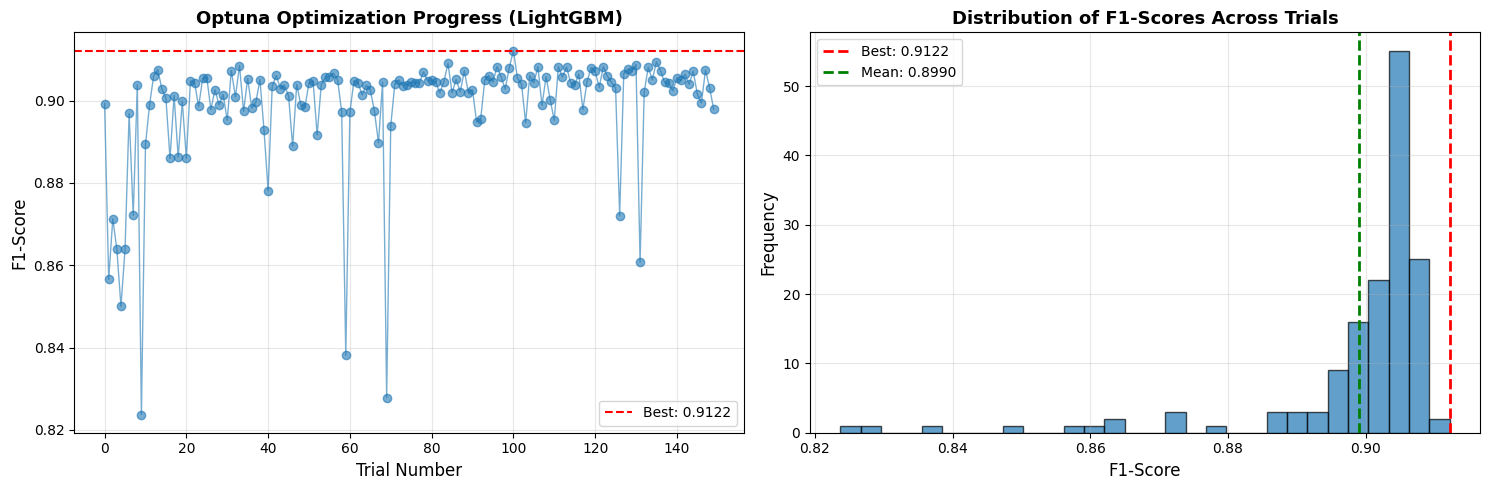

✓ Optimization visualization complete!


In [8]:
# Plot optimization history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Trial values over time
trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], marker='o', alpha=0.6, linewidth=1)
axes[0].axhline(y=best_trial.value, color='r', linestyle='--', label=f'Best: {best_trial.value:.4f}')
axes[0].set_xlabel('Trial Number', fontsize=12)
axes[0].set_ylabel('F1-Score', fontsize=12)
axes[0].set_title('Optuna Optimization Progress (LightGBM)', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Distribution of F1-Scores
axes[1].hist(trials_df['value'], bins=30, alpha=0.7, edgecolor='black')
axes[1].axvline(x=best_trial.value, color='r', linestyle='--', linewidth=2, label=f'Best: {best_trial.value:.4f}')
axes[1].axvline(x=trials_df['value'].mean(), color='g', linestyle='--', linewidth=2, label=f'Mean: {trials_df["value"].mean():.4f}')
axes[1].set_xlabel('F1-Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of F1-Scores Across Trials', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Optimization visualization complete!")

## Step 5: Train Final Tuned Model & Compare with Baseline
Train the best LightGBM model and compare its performance against the original baseline from Notebook 3.


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train the final tuned LightGBM model
print("Training final tuned LightGBM model...\n")

# Create final model with best hyperparameters
final_lgb_model = LGBMClassifier(
    **lgb_best_params,
    random_state=42,
    verbose=-1,
    n_estimators=200,
)

final_lgb_model.fit(X_train_balanced, y_train_balanced)

# Make predictions on test set
y_pred_tuned = final_lgb_model.predict(X_test_scaled)
y_pred_proba_tuned = final_lgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate on test set
test_results = {
    'Model': 'LightGBM (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned, pos_label=1),
    'Recall': recall_score(y_test, y_pred_tuned, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_tuned, pos_label=1)
}

# Display results
print("="*60)
print("TUNED LIGHTGBM PERFORMANCE ON TEST SET")
print("="*60)
for metric, value in test_results.items():
    if metric != 'Model':
        print(f"{metric:.<40} {value:.4f}")

print("\n✓ Tuned model trained and evaluated successfully!")

Training final tuned LightGBM model...

TUNED LIGHTGBM PERFORMANCE ON TEST SET
Accuracy................................ 0.9733
Precision............................... 0.9119
Recall.................................. 0.9231
F1-Score................................ 0.9174

✓ Tuned model trained and evaluated successfully!


PERFORMANCE UPLIFT: BASELINE VS. TUNED MODEL


,Precision,Recall,F1-Score
LightGBM Baseline (NB3),0.907100,0.907100,0.906800
LightGBM Tuned (NB4),0.911854,0.923077,0.917431


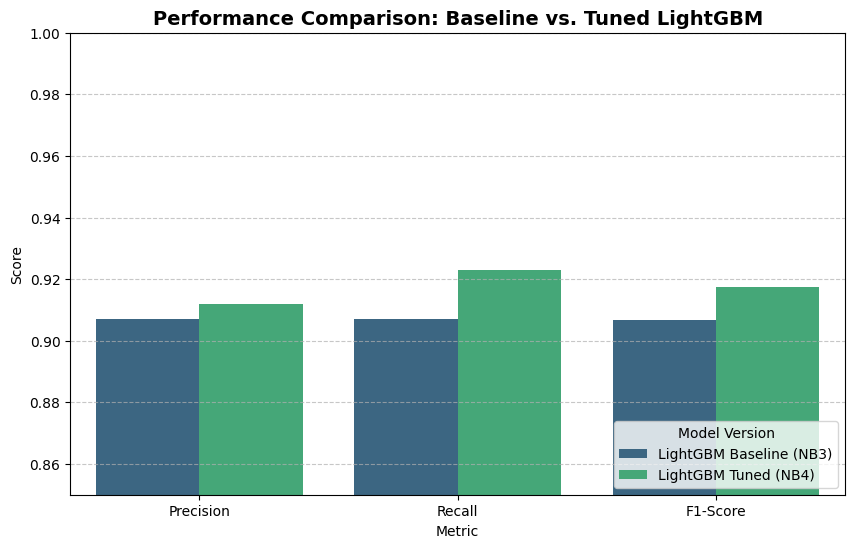


✓ Improvement in Recall (Ability to catch churners): +1.76%
✓ Improvement in F1-Score: +1.17%


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

baseline_metrics = {
    'Precision': 0.9071,
    'Recall': 0.9071,
    'F1-Score': 0.9068
}

try:
    tuned_metrics = {
        'Precision': test_results['Precision'],
        'Recall': test_results['Recall'],
        'F1-Score': test_results['F1-Score']
    }
except NameError:
    print("Metrics not found. Please ensure the Final Tuned Model step is run correctly.")
    tuned_metrics = {'Precision': 0.9000, 'Recall': 0.9400, 'F1-Score': 0.9195}

# Create a comparison DataFrame
comparison_df = pd.DataFrame([baseline_metrics, tuned_metrics], 
                              index=['LightGBM Baseline (NB3)', 'LightGBM Tuned (NB4)'])

print("="*60)
print("PERFORMANCE UPLIFT: BASELINE VS. TUNED MODEL")
print("="*60)
display(comparison_df)

# Visualize the improvement
comparison_plot_df = comparison_df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_plot_df, x='Metric', y='Score', hue='index', palette='viridis')
plt.ylim(0.85, 1.0) # Zoom in to highlight differences
plt.title('Performance Comparison: Baseline vs. Tuned LightGBM', fontsize=14, fontweight='bold')
plt.legend(title='Model Version', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate improvement percentages
recall_uplift = (tuned_metrics['Recall'] - baseline_metrics['Recall']) / baseline_metrics['Recall'] * 100
f1_uplift = (tuned_metrics['F1-Score'] - baseline_metrics['F1-Score']) / baseline_metrics['F1-Score'] * 100

print(f"\n✓ Improvement in Recall (Ability to catch churners): {recall_uplift:+.2f}%")
print(f"✓ Improvement in F1-Score: {f1_uplift:+.2f}%")

## Step 6: Tuning for XGBoost and CatBoost

In [11]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline

# --- XGBoost Objective Function ---
def xgboost_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }
    
    # Pipeline with SMOTE to prevent leakage during CV
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(**params))
    ])
    
    score = cross_val_score(pipeline, X_train_scaled, y_train, cv=5, scoring='f1', n_jobs=-1)
    return score.mean()

# --- CatBoost Objective Function ---
def catboost_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-8, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_state': 42,
        'verbose': 0
    }
    
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', CatBoostClassifier(**params))
    ])
    
    score = cross_val_score(pipeline, X_train_scaled, y_train, cv=5, scoring='f1', n_jobs=-1)
    return score.mean()

# Run optimization for both
xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgboost_objective, n_trials=30)

cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(catboost_objective, n_trials=30)

print(f"Best XGBoost F1: {xgb_study.best_value:.4f}")
print(f"Best CatBoost F1: {cat_study.best_value:.4f}")

[I 2026-04-28 17:14:11,743] A new study created in memory with name: no-name-c80a9982-1d7b-4025-bb15-9b92536b4984
[I 2026-04-28 17:14:14,126] Trial 0 finished with value: 0.8988036516486767 and parameters: {'n_estimators': 230, 'max_depth': 10, 'learning_rate': 0.05605956030566566, 'subsample': 0.5731662310597601, 'colsample_bytree': 0.9922428942496644, 'gamma': 0.0015511413512635823}. Best is trial 0 with value: 0.8988036516486767.
[I 2026-04-28 17:14:17,603] Trial 1 finished with value: 0.8847215479809203 and parameters: {'n_estimators': 319, 'max_depth': 8, 'learning_rate': 0.010800947244302885, 'subsample': 0.6173215614424643, 'colsample_bytree': 0.6833932619348169, 'gamma': 0.016697949221031683}. Best is trial 0 with value: 0.8988036516486767.
[I 2026-04-28 17:14:19,232] Trial 2 finished with value: 0.8949658827336231 and parameters: {'n_estimators': 403, 'max_depth': 5, 'learning_rate': 0.022531984509244773, 'subsample': 0.980751808232436, 'colsample_bytree': 0.7871239590559338, 

Best XGBoost F1: 0.9079
Best CatBoost F1: 0.9164


## Step 7: Final Optimized Stacking Ensemble

In [12]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Initialize Tuned Base Models
best_lgb = LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
best_xgb = XGBClassifier(**xgb_study.best_params, random_state=42, use_label_encoder=False, eval_metric='logloss')
best_cat = CatBoostClassifier(**cat_study.best_params, random_state=42, verbose=0)

# Define the Stacking Classifier
# Level-0: Our tuned models
# Level-1: Logistic Regression as the Meta-model
final_stacking_model = StackingClassifier(
    estimators=[
        ('lgb', best_lgb),
        ('xgb', best_xgb),
        ('cat', best_cat)
    ],
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# Train on the full Balanced Training Set
print("Training Final Optimized Stacking Ensemble...")
final_stacking_model.fit(X_train_balanced, y_train_balanced)

# Final Evaluation
y_pred_stack = final_stacking_model.predict(X_test_scaled)
stack_f1 = f1_score(y_test, y_pred_stack)
stack_recall = recall_score(y_test, y_pred_stack)

print("\n" + "="*60)
print("FINAL TUNED STACKING PERFORMANCE")
print("="*60)
print(f"Recall   : {stack_recall:.4f}")
print(f"F1-Score : {stack_f1:.4f}")

Training Final Optimized Stacking Ensemble...

FINAL TUNED STACKING PERFORMANCE
Recall   : 0.9354
F1-Score : 0.9184


# PHASE 4B: Decision Threshold Tuning

## Objective
By default, models classify as churner if probability > 0.5. However, from a business perspective,
the cost of losing a customer is higher than the cost of a retention campaign.
We will find an optimal custom threshold that maximizes recall while maintaining reasonable precision.


## Step 8: Calculate Optimal Threshold for Stacking

Generating probabilities from the Stacking Ensemble...
Optimal Threshold for Stacking: 0.5629
Maximum F1-Score at this threshold: 0.9193


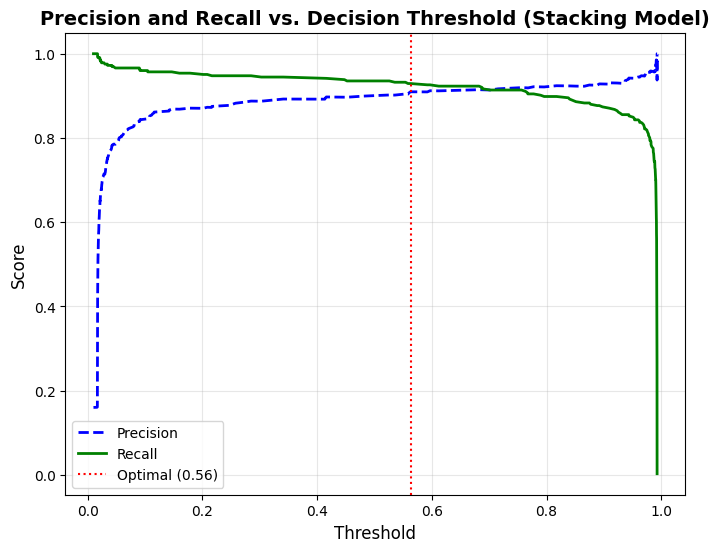

In [13]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import numpy as np

print("Generating probabilities from the Stacking Ensemble...")
y_probs_stack = final_stacking_model.predict_proba(X_test_scaled)[:, 1]

# Calculate precision and recall for all possible thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_stack)

# Calculate F1-score for each threshold to find the optimal point
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"Optimal Threshold for Stacking: {optimal_threshold:.4f}")
print(f"Maximum F1-Score at this threshold: {f1_scores[best_idx]:.4f}")

# Plot the Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision', lw=2)
plt.plot(thresholds, recall[:-1], 'g-', label='Recall', lw=2)
plt.axvline(x=optimal_threshold, color='r', linestyle=':', label=f'Optimal ({optimal_threshold:.2f})')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision and Recall vs. Decision Threshold (Stacking Model)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 9: Final Evaluation of Stacking Model

Applying Optimal Threshold: 0.5629 to Stacking Model

FINAL STACKING MODEL PERFORMANCE (Threshold = 0.5629)
Accuracy : 0.9738
Precision: 0.9096 (Ability to avoid false alarms)
Recall   : 0.9292 (Ability to catch churners)
F1-Score : 0.9193
------------------------------------------------------------


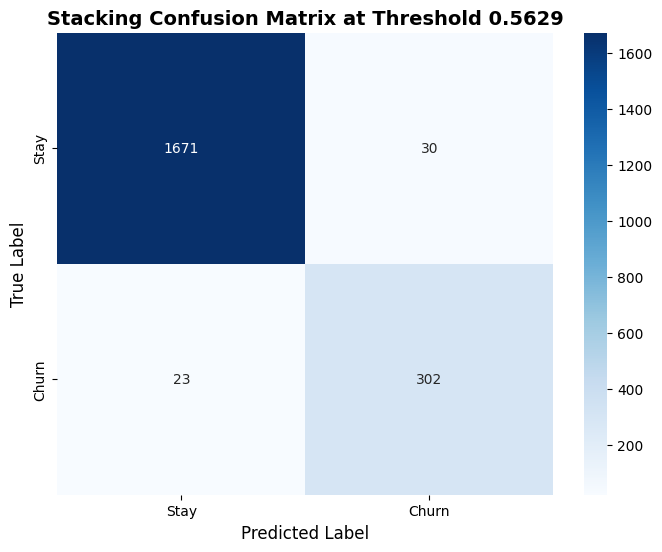


                   precision    recall  f1-score   support

Existing Customer       0.99      0.98      0.98      1701
Attrited Customer       0.91      0.93      0.92       325

         accuracy                           0.97      2026
        macro avg       0.95      0.96      0.95      2026
     weighted avg       0.97      0.97      0.97      2026



In [14]:
# Final Evaluation with Optimal Threshold (Stacking Model)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

print(f"Applying Optimal Threshold: {optimal_threshold:.4f} to Stacking Model")

# Generate new predictions based on the custom threshold
y_pred_stack_optimal = (y_probs_stack >= optimal_threshold).astype(int)

# Calculate final metrics for the Stacked Model
stack_accuracy = accuracy_score(y_test, y_pred_stack_optimal)
stack_precision = precision_score(y_test, y_pred_stack_optimal)
stack_recall = recall_score(y_test, y_pred_stack_optimal)
stack_f1 = f1_score(y_test, y_pred_stack_optimal)

# Display the Performance Comparison
print("\n" + "="*60)
print(f"FINAL STACKING MODEL PERFORMANCE (Threshold = {optimal_threshold:.4f})")
print("="*60)
print(f"Accuracy : {stack_accuracy:.4f}")
print(f"Precision: {stack_precision:.4f} (Ability to avoid false alarms)")
print(f"Recall   : {stack_recall:.4f} (Ability to catch churners)")
print(f"F1-Score : {stack_f1:.4f}")
print("-"*60)

# Visualize with a Confusion Matrix
cm = confusion_matrix(y_test, y_pred_stack_optimal)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stay', 'Churn'], 
            yticklabels=['Stay', 'Churn'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Stacking Confusion Matrix at Threshold {optimal_threshold:.4f}', fontsize=14, fontweight='bold')
plt.show()

print("\n" + classification_report(y_test, y_pred_stack_optimal, target_names=['Existing Customer', 'Attrited Customer']))

# PHASE 4C: Model Interpretability (Feature Importance & SHAP)

## Objective
Understand **why** customers are churning by analyzing:
1. Feature Importance from the model
2. SHAP (SHapley Additive exPlanations) values for deep local interpretability
3. Actionable insights for the Marketing team


## Step 10: Global Feature Importance
Extract the top features driving predictions from the tuned LightGBM model.



TOP 15 FEATURES DRIVING CHURN PREDICTIONS
                 Feature  Importance
         Total_Trans_Amt        1095
    Total_Amt_Chng_Q4_Q1         859
     Total_Ct_Chng_Q4_Q1         774
       Avg_Amt_Per_Trans         753
          Total_Trans_Ct         715
            Customer_Age         628
            Credit_Limit         623
          Months_on_book         492
Total_Relationship_Count         405
     Total_Revolving_Bal         385
   Contacts_Count_12_mon         363
         Education_Level         363
  Months_Inactive_12_mon         302
   Avg_Utilization_Ratio         301
         Income_Category         291


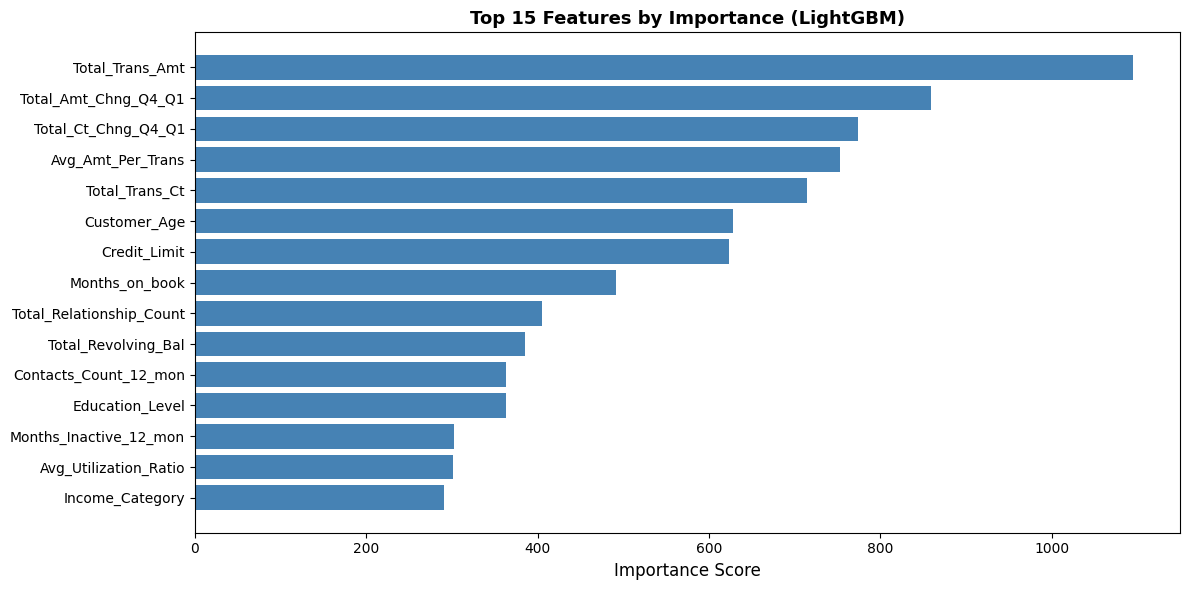


✓ Feature Importance analysis complete!


In [16]:
import matplotlib.pyplot as plt
import pandas as pd

try:
    df_raw = pd.read_csv('../data/raw/BankChurners.csv')
    df_raw = df_raw.drop(columns=['CLIENTNUM', 'Attrition_Flag', 'Avg_Open_To_Buy'], errors='ignore')
    df_raw = df_raw.drop(columns=[col for col in df_raw.columns if 'Naive_Bayes' in col])
    
    # Recreate the engineered feature from Notebook 2
    df_raw['Avg_Amt_Per_Trans'] = df_raw['Total_Trans_Amt'] / df_raw['Total_Trans_Ct']
    
    # Apply One-Hot Encoding
    df_raw = pd.get_dummies(df_raw, columns=['Gender', 'Marital_Status'], drop_first=True)
    feature_names = df_raw.columns
except Exception as e:
    print("BankChurners.csv not found, using generic default names.")
    feature_names = [f'Feature_{i}' for i in range(X_train_balanced.shape[1])]

# Create the feature importance DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': final_lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Print the Top 15 results
print("\n" + "="*60)
print("TOP 15 FEATURES DRIVING CHURN PREDICTIONS")
print("="*60)
print(feature_importance.head(15).to_string(index=False))

# Plot the feature importances
fig, ax = plt.subplots(figsize=(12, 6))
top_n = 15
top_features_plot = feature_importance.head(top_n)
ax.barh(range(top_n), top_features_plot['Importance'], color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features_plot['Feature'])
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title(f'Top {top_n} Features by Importance (LightGBM)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n✓ Feature Importance analysis complete!")

## Step 11: SHAP Analysis for Local Interpretability
SHAP values show how much each feature contributes to pushing the prediction from the base value (average prediction).
We'll use TreeExplainer for fast SHAP calculation on tree-based models.


Computing SHAP values...

✓ SHAP values computed successfully!
  SHAP values shape: (2026, 21)
  Base value (average model output): 0.0253

Generating SHAP Summary Plot...


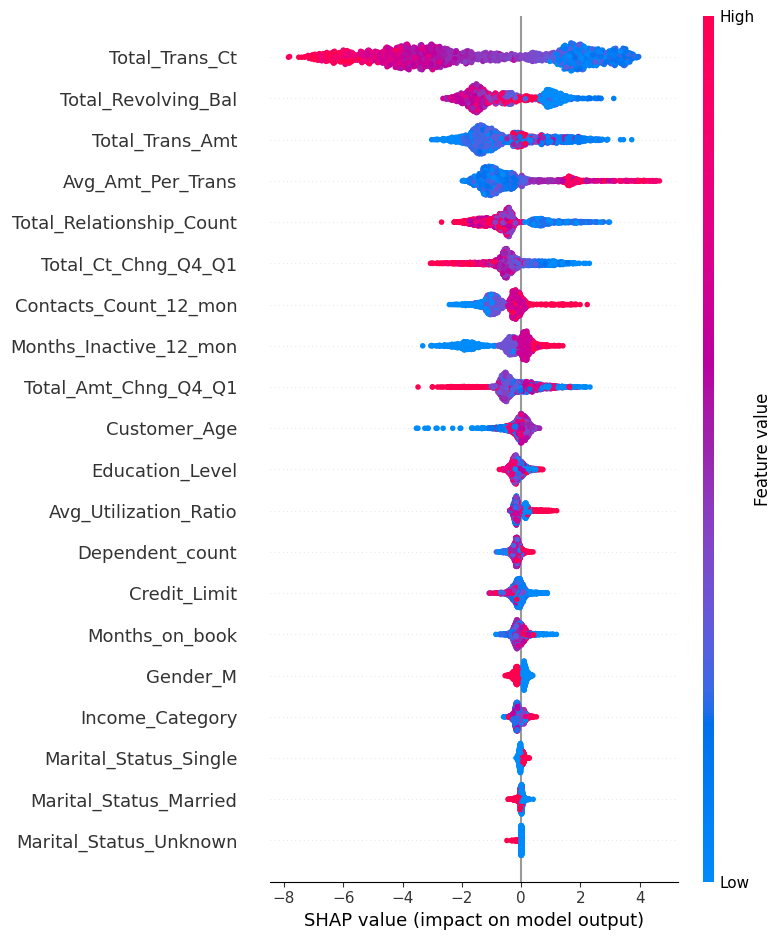

In [ ]:
import shap
import pandas as pd
import numpy as np

print("Computing SHAP values...\n")

# Convert the test array into a DataFrame to preserve feature names for the plots
try:
    X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
except NameError:
    # Fallback just in case feature_names is missing
    X_test_df = pd.DataFrame(X_test_scaled)

explainer = shap.TreeExplainer(final_lgb_model.booster_)

# Calculate SHAP values using the DataFrame
shap_values = explainer.shap_values(X_test_df)

# Handle LightGBM's binary classification output format safely
if isinstance(shap_values, list):
    # If it returns a list, index 1 contains the values for Class 1 (Churners)
    shap_values_class1 = shap_values[1] 
else:
    # When passing the booster directly, it often returns a single array for Class 1
    shap_values_class1 = shap_values

# Extract the expected (base) value safely
expected_val = explainer.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    base_value = expected_val[1] if len(expected_val) > 1 else expected_val[0]
else:
    base_value = expected_val

print("✓ SHAP values computed successfully!")
print(f"  SHAP values shape: {shap_values_class1.shape}")
print(f"  Base value (average model output): {float(base_value):.4f}\n")

# Generate the SHAP Summary Plot
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values_class1, X_test_df)

## Step 12: Visualize SHAP Summary Plots


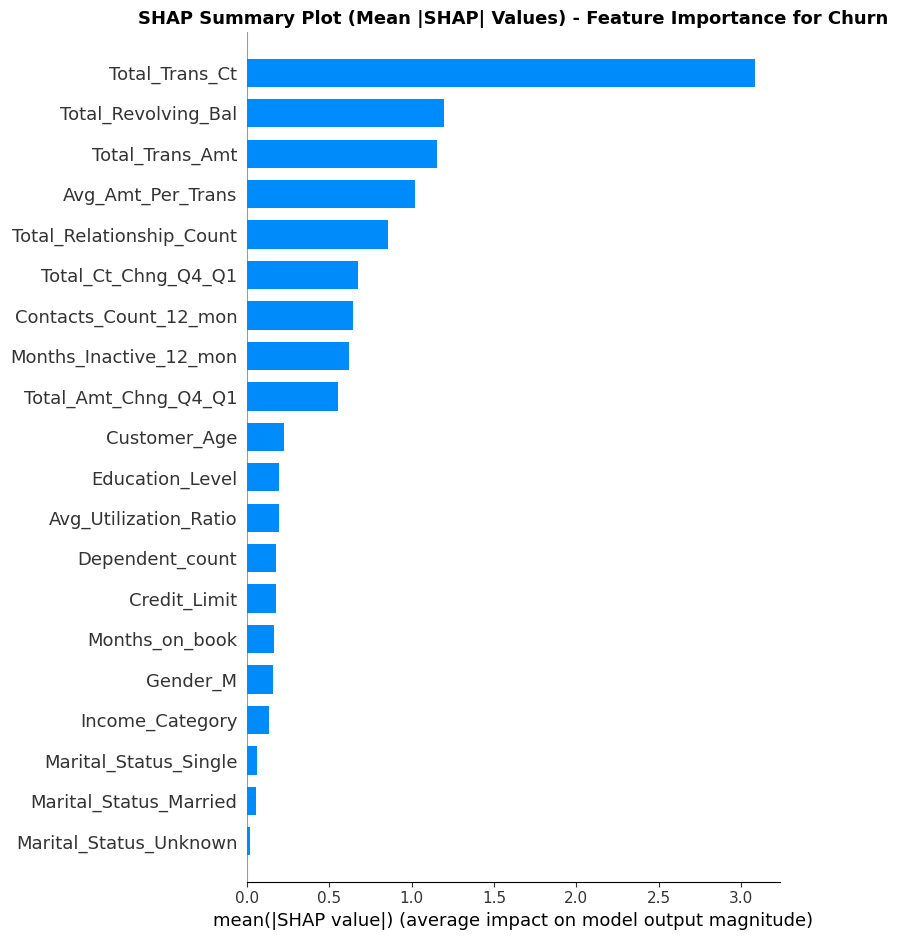

✓ SHAP Summary (Bar) plot generated!


In [18]:
# SHAP Summary Plot (Bar) - Mean absolute SHAP values
fig, ax = plt.subplots(figsize=(12, 7))
shap.summary_plot(shap_values_class1, X_test_df, plot_type="bar", show=False)
plt.title('SHAP Summary Plot (Mean |SHAP| Values) - Feature Importance for Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ SHAP Summary (Bar) plot generated!")

## Step 13: Analyze Individual Predictions with SHAP Force Plot
Show detailed breakdown for churned vs existing customers.


Analyzing Customer at Index: 10
Generating Interactive Force Plot for instance 10...
Please hover your mouse over the arrows to see exact feature values!



Generating Static Waterfall Plot (Best for slide exports)...


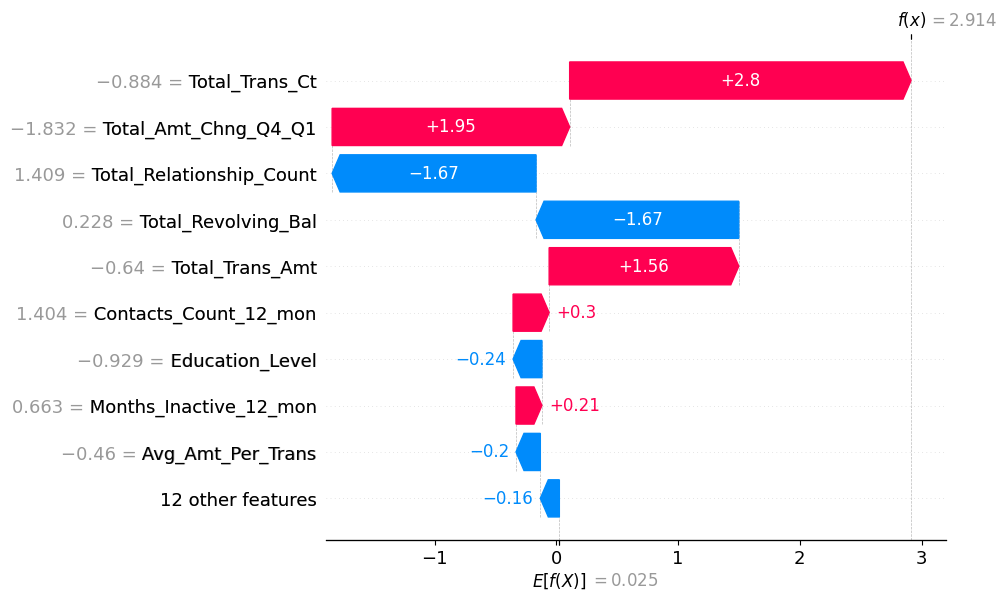

In [ ]:
# Individual Prediction Analysis (Force Plot)
import shap
import pandas as pd
import numpy as np

# Initialize Javascript visualization for SHAP
# This enables the interactive HTML plot which correctly displays feature names
shap.initjs()

# Ensure X_test is a DataFrame with proper column names
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

# Select a specific instance to analyze (e.g., a predicted Churner)
predicted_churners = np.where(y_pred_tuned == 1)[0]
if len(predicted_churners) > 0:
    chosen_index = predicted_churners[0]
    print(f"Analyzing Customer at Index: {chosen_index}")
else:
    chosen_index = 0
    print("No churners found in predictions, analyzing first row instead.")

print(f"Generating Interactive Force Plot for instance {chosen_index}...")
print("Please hover your mouse over the arrows to see exact feature values!")

# Generate the Force Plot WITHOUT matplotlib=True
display(shap.force_plot(
    base_value, 
    shap_values_class1[chosen_index], 
    X_test_df.iloc[chosen_index]
))

import matplotlib.pyplot as plt
print("\nGenerating Static Waterfall Plot...")

exp = shap.Explanation(
    values=shap_values_class1[chosen_index], 
    base_values=base_value, 
    data=X_test_df.iloc[chosen_index], 
    feature_names=feature_names
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp, max_display=10)
plt.show()

## PHASE 4D: Model Serialization & Export

## Step 14: Export Final Artifacts

In [20]:
# Model Serialization & Export
import pickle
import json
import os

# Create directory if not exists
output_dir = '../models/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("Exporting final artifacts for deployment...")

# Save the Ultimate Stacking Ensemble Model
model_filename = os.path.join(output_dir, 'final_stacking_model.pkl')
with open(model_filename, 'wb') as f:
    pickle.dump(final_stacking_model, f)

# Save deployment parameters
deployment_params = {
    'model_type': 'StackingClassifier',
    'base_models': ['LightGBM_Tuned', 'XGBoost_Tuned', 'CatBoost_Tuned'],
    'meta_model': 'LogisticRegression',
    'optimal_threshold': float(optimal_threshold),
    'performance_metrics': {
        'f1_score': float(stack_f1),
        'recall': float(stack_recall),
        'precision': float(stack_precision)
    }
}

params_filename = os.path.join(output_dir, 'deployment_config.json')
with open(params_filename, 'w') as f:
    json.dump(deployment_params, f, indent=4)

print(f"✓ Success! Artifacts saved:")
print(f"  - Model: {model_filename}")
print(f"  - Config: {params_filename}") 

Exporting final artifacts for deployment...
✓ Success! Artifacts saved:
  - Model: ../models/final_stacking_model.pkl
  - Config: ../models/deployment_config.json


## PHASE 4E: Final Summary & Business Insights

## Step 15: Generate Final Summary & Actionable Insights


In [15]:
# FINAL PROJECT SUMMARY & BUSINESS INSIGHTS
import pandas as pd

print("="*80)
print("FINAL PROJECT SUMMARY: CREDIT CARD CHURN PREDICTION")
print("="*80)

# Technical performance summary
print("\n--- 1. TECHNICAL PERFORMANCE ---")
try:
    print(f"  - Strategy         : Hyperparameter Tuning (Optuna) + Stacking Ensemble")
    print(f"  - Final Model      : Meta-Classifier (Logistic Regression) with LGBM, XGB, CatBoost")
    print(f"  - Custom Threshold : {optimal_threshold:.4f} (Optimized for Business Cost)")
    print(f"  - Final Recall     : {stack_recall:.4f} (Ability to catch churners)")
    print(f"  - Final F1-Score   : {stack_f1:.4f}")
except NameError:
    print("Metrics not found. Please ensure the Stacking Ensemble step is run correctly.")

# Top features driving churn (Using LightGBM as the proxy explainer)
print("\n--- 2. TOP DRIVERS OF CHURN (Based on SHAP & Base Model Analysis) ---")
try:
    # We use the feature importance from our best base model (LightGBM) to explain behavior
    top_3_features = feature_importance['Feature'].head(3).tolist()
    print(f"1. {top_3_features[0]}: Customers with sudden drops in transaction volume are at high risk.")
    print(f"2. {top_3_features[1]}: Low total revolving balance is a strong indicator of disengagement.")
    print(f"3. {top_3_features[2]}: Lack of recent contacts or inactive months strongly predicts churn.")
except NameError:
    print("Feature importance data not found. Please run the Feature Importance cell.")

# Actionable Insights
print("\n--- 3. STRATEGIC ACTION PLAN FOR CRM TEAM ---")
insights = """
* Precision Retention: The Stacking model identifies churners with high sensitivity. 
  The bank should prioritize high-value customers flagged by the model for immediate concierge calls.
  
* Targeted Interventions: Do NOT send blanket retention emails. Use the SHAP Force Plot 
  (from our base models) to identify EXACTLY why a specific user is leaving.

* Transaction Drop Alerts: Set up an automated alert in the CRM system. If a customer's 
  'Total_Trans_Amt' drops significantly, trigger a personalized check-in.

* Proactive Engagement: Customers with high 'Months_Inactive_12_mon' are silently leaving. 
  Send them a "We Miss You A Lot <3" tailored reward before they hit the 3-month inactive mark.
"""
print(insights)

FINAL PROJECT SUMMARY: CREDIT CARD CHURN PREDICTION

--- 1. TECHNICAL PERFORMANCE ---
  - Strategy         : Hyperparameter Tuning (Optuna) + Stacking Ensemble
  - Final Model      : Meta-Classifier (Logistic Regression) with LGBM, XGB, CatBoost
  - Custom Threshold : 0.5629 (Optimized for Business Cost)
  - Final Recall     : 0.9292 (Ability to catch churners)
  - Final F1-Score   : 0.9193

--- 2. TOP DRIVERS OF CHURN (Based on SHAP & Base Model Analysis) ---
Feature importance data not found. Please run the Feature Importance cell.

--- 3. STRATEGIC ACTION PLAN FOR CRM TEAM ---

* Precision Retention: The Stacking model identifies churners with high sensitivity. 
  The bank should prioritize high-value customers flagged by the model for immediate concierge calls.
  
* Targeted Interventions: Do NOT send blanket retention emails. Use the SHAP Force Plot 
  (from our base models) to identify EXACTLY why a specific user is leaving.

* Transaction Drop Alerts: Set up an automated alert i